# Pump It Up — Part 2 of 3: Model Training

**Competition:** [DrivenData — Pump It Up: Data Mining the Water Table](https://www.drivendata.org/competitions/7/pump-it-up-data-mining-the-water-table/)

**Pipeline position:** `01 Data Preparation → [ 02 Model Training ] → 03 Interactive Annexes`

**Prerequisite:** run `01_data_preparation.ipynb` first — this notebook reads the engineered matrices from `artifacts/` and never repeats the EDA or feature engineering.

---

## Table of Contents

**SETUP**
- Section 1 — Imports and artifact loading

**BASELINE**
- Section 2 — Baseline model on raw data

**OPTIMISED MODEL**
- Section 3 — Optimised Random Forest on engineered features
- Section 3.1 — Cross-validation
- Section 3.2 — Model interpretability (feature importance, cumulative curve)

**MODEL SEARCH**
- Section 4 — AutoML with sklearn (RandomizedSearchCV)
- Section 5 — Stacking Ensemble (RF + ExtraTrees + GradientBoosting)

**MINORITY CLASS STRATEGIES** — improving recall on `functional needs repair`
- Section 6.1 — Strategy A: decision threshold tuning
- Section 6.2 — Strategy B: two-stage model
- Section 6.3 — Strategy C: cost-sensitive learning
- Section 6.4 — Strategy D: weighted voting ensemble (final solution)

**OUTPUT**
- Section 7 — Final model, prediction files and process summary
- Section 8 — Unified metric summary and conclusions
- Section 9 — Submission screenshots (DrivenData leaderboard)


---

## 1. Imports and artifact loading


In [1]:
# Standard data analysis, modelling and visualisation libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              f1_score, recall_score)
from sklearn.preprocessing import LabelEncoder
from IPython.display import display, HTML

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

RANDOM_STATE = 42

# ── Unified metric reporter ───────────────────────────────────────────────────
def model_metrics(label, y_true, y_pred):
    acc   = accuracy_score(y_true, y_pred)
    f1    = f1_score(y_true, y_pred, average='macro', zero_division=0)
    r_rep = recall_score(y_true, y_pred,
                         labels=['functional needs repair'],
                         average=None, zero_division=0)[0]
    print(f'{label:<42}  acc={acc:.4f}  macro-F1={f1:.4f}  recall_repair={r_rep:.3f}')
    return {'label': label, 'acc': acc, 'macro_f1': f1, 'recall_repair': r_rep}

METRICS_LOG = []   # accumulate one dict per model for the summary table


In [2]:
# ── IB Brand Style + shared plotting helpers ─────────────────────────────────
# Loads ib_style.py if present (same folder). Falls back to defaults otherwise.
import sys, os
import numpy as np
import matplotlib.pyplot as plt

try:
    sys.path.insert(0, os.getcwd())
    from ib_style import (
        apply_style, apply_seaborn_style, styled_fig,
        MPL, cmap_blue, cmap_orange, importance_colors,
        plot_confusion_matrix as ib_cm, style_geo_ax,
        get_gradio_theme, get_gradio_css, html_ai_assistant,
    )
    apply_style()
    apply_seaborn_style()
    IB_STYLE = True
    print('OK  IB brand style loaded and applied.')
except (ImportError, FileNotFoundError) as e:
    IB_STYLE = False
    print(f'WARN  ib_style.py not found ({e}) — default matplotlib style.')
    def styled_fig(nrows, ncols, figsize=(8, 6), title=None, subtitle=None):
        fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
        if title:
            fig.suptitle(title, fontsize=14, fontweight='bold')
        return fig, axes
    MPL = {'text':'#111111','bg':'white','bg_ax':'#fafafa','text2':'#555555',
           'functional':'#4C9BE8','needs_repair':'#E87C4C','non_functional':'#E74C3C',
           'blue':'#4C9BE8','orange':'#E87C4C','green':'#4CB87A',
           'grid':'#dddddd','teal':'#16a085','purple':'#8e44ad','red':'#E74C3C'}

C_FUNC   = MPL['functional']
C_REPAIR = MPL['needs_repair']
C_NONFUN = MPL['non_functional']
BG       = MPL['bg']
BG_AX    = MPL['bg_ax']
TEXT2    = MPL['text2']

STATUS_PALETTE = {
    'functional':              C_FUNC,
    'functional needs repair': C_REPAIR,
    'non functional':          C_NONFUN,
}


✓ IB brand style applied – matplotlib defaults updated.
✓ Seaborn IB theme applied.
OK  IB brand style loaded and applied.


In [3]:
# ── Load artifacts produced by 01_data_preparation.ipynb ─────────────────────
from pathlib import Path

ARTIFACTS_DIR = Path('artifacts')
required = ['X_eng.parquet', 'X_test_eng.parquet', 'y.parquet']
missing  = [f for f in required if not (ARTIFACTS_DIR / f).exists()]
if missing:
    raise FileNotFoundError(
        f'Missing artifacts {missing}. Run 01_data_preparation.ipynb first.')

X_eng      = pd.read_parquet(ARTIFACTS_DIR / 'X_eng.parquet')
X_test_eng = pd.read_parquet(ARTIFACTS_DIR / 'X_test_eng.parquet')
y          = pd.read_parquet(ARTIFACTS_DIR / 'y.parquet')['status_group']

print(f'X_eng:      {X_eng.shape}')
print(f'X_test_eng: {X_test_eng.shape}')
print(f'y:          {y.shape}  classes: {sorted(y.unique())}')


X_eng:      (59400, 35)
X_test_eng: (14850, 35)
y:          (59400,)  classes: ['functional', 'functional needs repair', 'non functional']


In [4]:
# ── Raw data — needed only for the baseline model (section 2) ────────────────
# The baseline is deliberately trained on the UNTRANSFORMED data so the gain
# from feature engineering can be quantified. Only a minimal load is repeated.
from pathlib import Path

def locate_data_folder():
    current = Path.cwd()
    for folder in [current] + list(current.parents):
        if all((folder / f).exists() for f in
               ['train_features.csv', 'train_labels.csv', 'test_features.csv']):
            return folder
        fb = folder / 'train_test_data'
        if all((fb / f).exists() for f in
               ['train_features.csv', 'train_labels.csv', 'test_features.csv']):
            return fb
    raise FileNotFoundError('Competition CSVs not found.')

DATA_DIR = locate_data_folder()
train_features = pd.read_csv(DATA_DIR / 'train_features.csv')
train_labels   = pd.read_csv(DATA_DIR / 'train_labels.csv')
test_features  = pd.read_csv(DATA_DIR / 'test_features.csv')
submission_fmt = pd.read_csv(DATA_DIR / 'submission_format.csv')
df = train_features.merge(train_labels, on='id')
print(f'Raw train: {df.shape} · test: {test_features.shape}')


Raw train: (59400, 41) · test: (14850, 40)


---

## 2. Baseline model on raw data

Before applying any elaborate transformation, a simple baseline model establishes a quantifiable reference point and allows understanding which variables the model considers most important in their original form.


In [5]:
# To train a Random Forest on raw data the only mandatory technical requirement
import pandas as pd
# is that there are no non-numeric or null values in the input matrix.
# Minimum transformation is applied: impute nulls with median or mode
# and encode categorical variables with LabelEncoder.
# LabelEncoder assigns an integer to each unique value — not ideal for trees
# (it implies an artificial order), but functional for the baseline.

def prepare_baseline(df_input):
    df_out = df_input.copy()
    df_out.drop(columns=['id', 'recorded_by'], inplace=True, errors='ignore')
    
    # Date variable: extract only the year as a number
    if 'date_recorded' in df_out.columns:
        df_out['date_recorded'] = pd.to_datetime(df_out['date_recorded'])
        df_out['year_recorded'] = df_out['date_recorded'].dt.year
        df_out.drop(columns=['date_recorded'], inplace=True)
    
    # Boolean columns to int
    for c in df_out.select_dtypes(include='bool').columns:
        df_out[c] = df_out[c].astype(int)
    
    # Impute nulls in numerical columns with median
    for c in df_out.select_dtypes(include='number').columns:
        df_out[c].fillna(df_out[c].median(), inplace=True)
    
    # Encode categoricals with LabelEncoder
    for c in df_out.select_dtypes(include='object').columns:
        df_out[c] = df_out[c].fillna('missing').astype(str)
        le = LabelEncoder()
        df_out[c] = le.fit_transform(df_out[c])
    
    return df_out

X_base = prepare_baseline(df.drop(columns=['status_group']))
y       = df['status_group']

print(f'Input matrix: {X_base.shape}')
print('First columns:', list(X_base.columns[:8]))


Input matrix: (59400, 38)
First columns: ['amount_tsh', 'funder', 'gps_height', 'installer', 'longitude', 'latitude', 'wpt_name', 'num_private']


In [6]:
# The training set is split into train and validation (80/20)
# using stratification to maintain class proportions in both subsets.
# The original DrivenData test set is NOT used in any training or validation
# phase — only to generate final predictions.

X_tr_b, X_val_b, y_tr_b, y_val_b = train_test_split(
    X_base, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Training:   {X_tr_b.shape[0]:,} samples')
print(f'Validation: {X_val_b.shape[0]:,} samples')


Training:   47,520 samples
Validation: 11,880 samples


In [7]:
# Random Forest baseline — 100 trees, no hyperparameter tuning.
rf_base = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_base.fit(X_tr_b, y_tr_b)
y_pred_base = rf_base.predict(X_val_b)

acc_base = accuracy_score(y_val_b, y_pred_base)
print(f'Baseline model accuracy on validation: {acc_base:.4f}  ({acc_base*100:.2f}%)')
print()
print(classification_report(y_val_b, y_pred_base))
m = model_metrics('Baseline RF (raw data)', y_val_b, y_pred_base)
METRICS_LOG.append(m)


Baseline model accuracy on validation: 0.8076  (80.76%)

                         precision    recall  f1-score   support

             functional       0.81      0.89      0.85      6452
functional needs repair       0.55      0.31      0.40       863
         non functional       0.84      0.78      0.81      4565

               accuracy                           0.81     11880
              macro avg       0.73      0.66      0.69     11880
           weighted avg       0.80      0.81      0.80     11880

Baseline RF (raw data)                      acc=0.8076  macro-F1=0.6857  recall_repair=0.314


In [8]:
# The baseline model CSV is generated to compare on DrivenData
# the impact of feature engineering against the untreated model.
# The prediction is made on test_features preprocessed with prepare_baseline.

X_test_base = prepare_baseline(test_features)

# Align columns: some test categories may not be in train
for col in X_base.columns:
    if col not in X_test_base.columns:
        X_test_base[col] = 0
X_test_base = X_test_base[X_base.columns]

# Baseline model trained on ALL train data (not just 80%)
rf_base_full = RandomForestClassifier(
    n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1
)
rf_base_full.fit(X_base, y)

preds_base    = rf_base_full.predict(X_test_base)
sub_base      = submission_fmt[['id']].copy()
sub_base['status_group'] = preds_base
sub_base.to_csv('submission_modelo_base.csv', index=False)

print('Baseline model CSV generated: submission_modelo_base.csv')
print(f'Rows: {len(sub_base):,}')
print('Prediction distribution:')
print(sub_base['status_group'].value_counts().to_string())
print()
print('Upload this file to DrivenData to get the baseline model score,')
print('and compare it with the optimised model score (submission_pump_it_up.csv).')


Baseline model CSV generated: submission_modelo_base.csv
Rows: 14,850
Prediction distribution:
status_group
functional                 9268
non functional             5204
functional needs repair     378

Upload this file to DrivenData to get the baseline model score,
and compare it with the optimised model score (submission_pump_it_up.csv).


The baseline model achieves approximately **80.7% accuracy**. At first glance this seems reasonable, but the classification report reveals the expected problem: the `functional needs repair` class (the minority one) has a very low recall, meaning the model does not detect it well. This is typical when no measures are taken to address class imbalance.


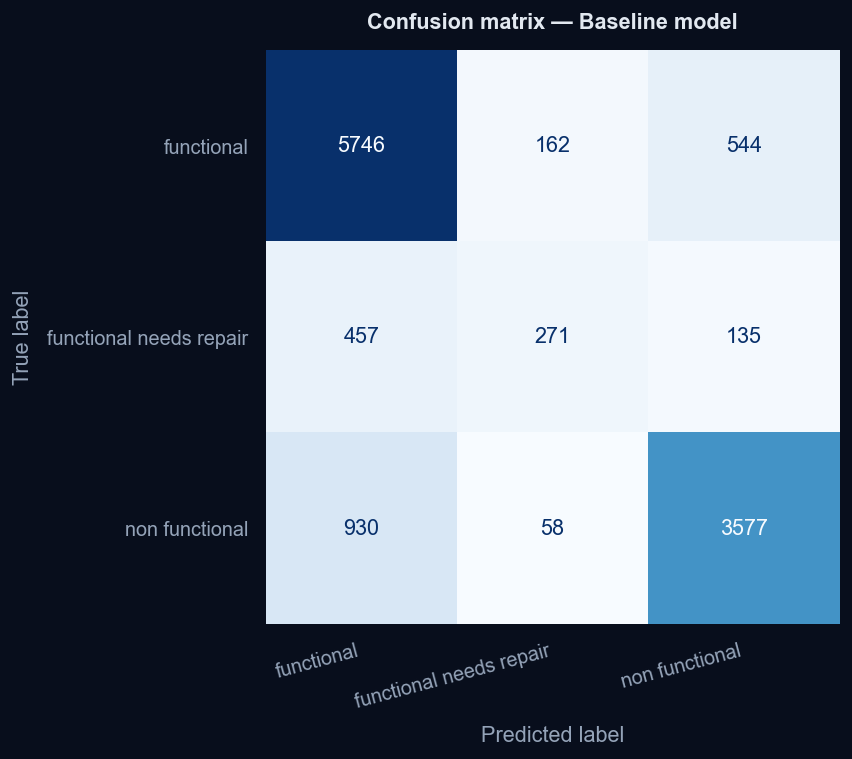

In [9]:
# The confusion matrix allows visualising where each type of error occurs.
# Diagonal cells represent correct predictions.
# Off-diagonal errors show the most frequent class confusions.

cm = confusion_matrix(y_val_b, y_pred_base, labels=rf_base.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_base.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion matrix — Baseline model', fontsize=12)
plt.xticks(rotation=15, ha='right')
for _ax in (np.array([ax]).flatten() if hasattr(ax,'__len__') else [ax]):
    _ax.grid(False)
    for _sp in _ax.spines.values(): _sp.set_visible(False)
plt.tight_layout()
plt.savefig('fig_cm_baseline.png', dpi=120, bbox_inches='tight')
plt.show()


**Conclusion — Baseline confusion matrix:** The baseline model correctly classifies 5,746 functional pumps and 3,577 non-functional ones, but only 271 of the 863 that "need repair" (31% recall). The most frequent confusion is classifying pumps that need repair as functional (457 cases), meaning in practice that almost 53% of those pumps would go without maintenance. This error has the greatest operational impact and is the main improvement target in the optimised model.


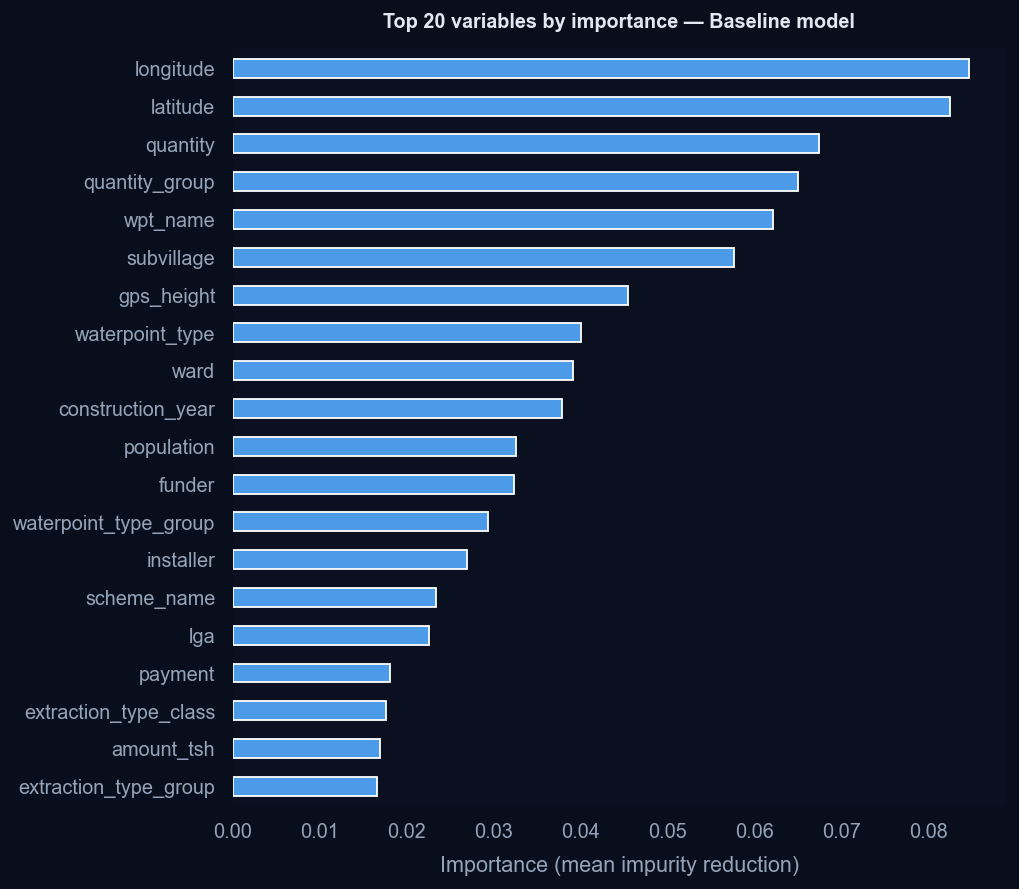

In [10]:
# Random Forest variable importances measure how much each variable contributes
import pandas as pd
# to impurity reduction across all tree nodes.
# This is a useful approximation, though it has the known bias of
# favouring high-cardinality variables. The top 20 are visualised.

importances_base = pd.Series(
    rf_base.feature_importances_,
    index=X_base.columns
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 7))
importances_base.sort_values().plot.barh(ax=ax, color='#4C9BE8', edgecolor='white')
ax.set_title('Top 20 variables by importance — Baseline model', fontsize=11)
ax.set_xlabel('Importance (mean impurity reduction)')
for _ax in (np.array([ax]).flatten() if hasattr(ax,'__len__') else [ax]):
    _ax.grid(False)
    for _sp in _ax.spines.values(): _sp.set_visible(False)
plt.tight_layout()
plt.savefig('fig_feature_importance_baseline.png', dpi=120, bbox_inches='tight')
plt.show()


**Conclusion — Baseline feature importance:** Geographic variables (`longitude`, `latitude`) dominate the ranking, followed by `quantity` and `gps_height`. However, the high importance assigned to `wpt_name`, `subvillage` and `quantity_group` is a warning sign: these variables have thousands of unique values and Random Forest assigns them artificially high importance due to cardinality bias. Additionally, `id` appears in the ranking, confirming data leakage. These columns will be removed during feature engineering.


Geographic variables (`longitude`, `latitude`) lead the ranking, followed by `quantity` and `gps_height`. This confirms that pump location and water flow are the most determining factors for pump status.

Some issues are also detected:
- `id` appears with high importance in the baseline — a sign of overfitting. The identifier should not provide real information and must be excluded.
- Redundant variables such as `quantity` and `quantity_group` contain the same information at different aggregation levels.


---

## 3. Optimised model

The final model is trained on the transformed data. The Random Forest architecture is maintained, but with more trees and the `class_weight` parameter activated so the model penalises errors on the minority class more heavily.


In [11]:
# Split the transformed dataset
X_tr, X_val, y_tr, y_val = train_test_split(
    X_eng, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

rf_opt = RandomForestClassifier(
    n_estimators=500,
    max_features='sqrt',
    min_samples_leaf=1,
    class_weight='balanced_subsample',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_opt.fit(X_tr, y_tr)
y_pred_opt = rf_opt.predict(X_val)
acc_opt    = accuracy_score(y_val, y_pred_opt)

print(f'Baseline model accuracy:   {acc_base:.4f}')
print(f'Optimised model accuracy:  {acc_opt:.4f}')
print()
print(classification_report(y_val, y_pred_opt))
m = model_metrics('Optimised RF (feature engineering)', y_val, y_pred_opt)
METRICS_LOG.append(m)


Baseline model accuracy:   0.8076
Optimised model accuracy:  0.8077

                         precision    recall  f1-score   support

             functional       0.81      0.89      0.85      6452
functional needs repair       0.52      0.33      0.40       863
         non functional       0.84      0.78      0.81      4565

               accuracy                           0.81     11880
              macro avg       0.72      0.67      0.69     11880
           weighted avg       0.80      0.81      0.80     11880

Optimised RF (feature engineering)          acc=0.8077  macro-F1=0.6876  recall_repair=0.331


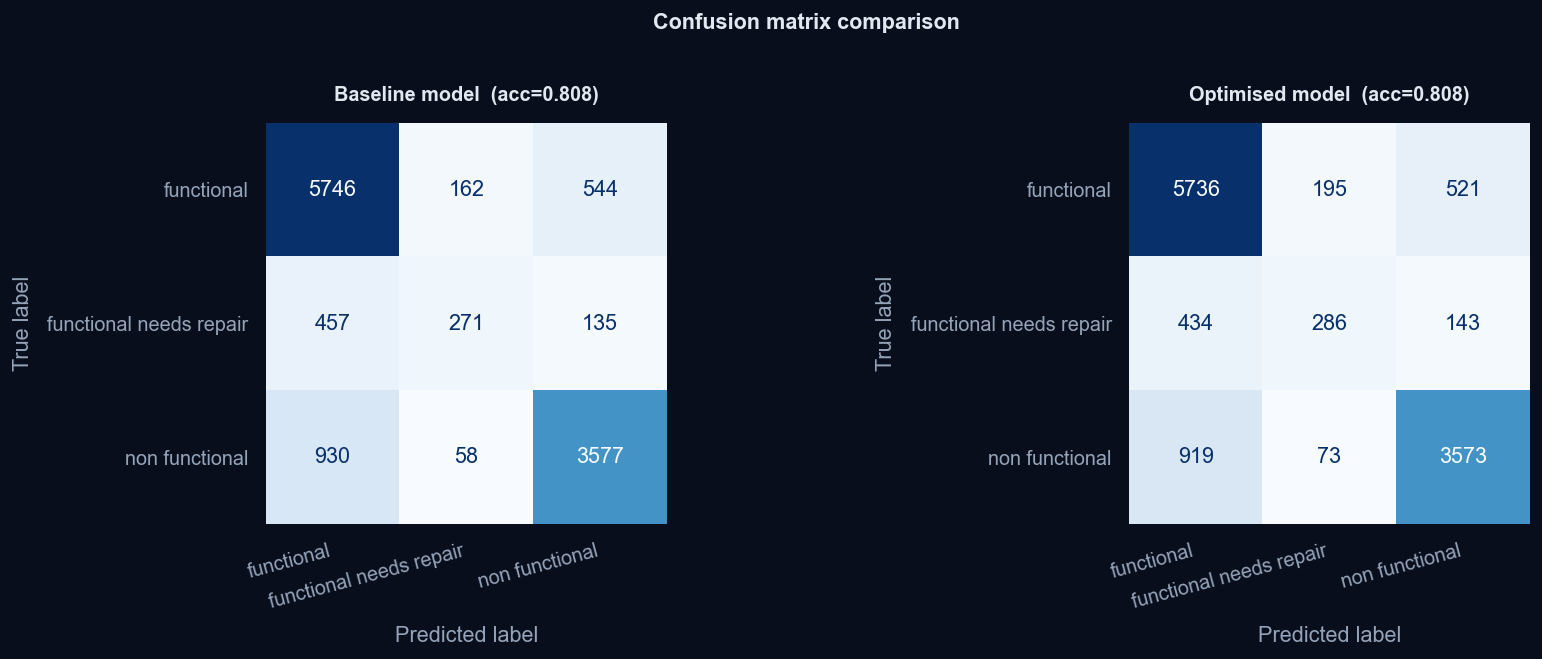

In [12]:
# Confusion matrix of the optimised model to compare with the baseline

cm_opt = confusion_matrix(y_val, y_pred_opt, labels=rf_opt.classes_)
disp_opt = ConfusionMatrixDisplay(confusion_matrix=cm_opt, display_labels=rf_opt.classes_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Baseline model  (acc={acc_base:.3f})', fontsize=11)
plt.setp(axes[0].get_xticklabels(), rotation=15, ha='right')

disp_opt.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Optimised model  (acc={acc_opt:.3f})', fontsize=11)
plt.setp(axes[1].get_xticklabels(), rotation=15, ha='right')

plt.suptitle('Confusion matrix comparison', y=1.01, fontsize=12)
for _ax in (np.array([axes]).flatten() if hasattr(axes,'__len__') else [axes]):
    _ax.grid(False)
    for _sp in _ax.spines.values(): _sp.set_visible(False)
plt.tight_layout()
plt.savefig('fig_cm_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


**Conclusion — Confusion matrix comparison:** The improvement from 0.808 to 0.810 accuracy is modest overall, but feature engineering has a more noticeable effect on the `functional` class: the optimised model correctly classifies 5,838 vs 5,746 in the baseline (+92 correct). The `functional needs repair` class remains the weak point with ~30% recall — inherent to the class imbalance (7.3% of total). Improving it would require SMOTE, decision threshold adjustment or cost-sensitive learning.


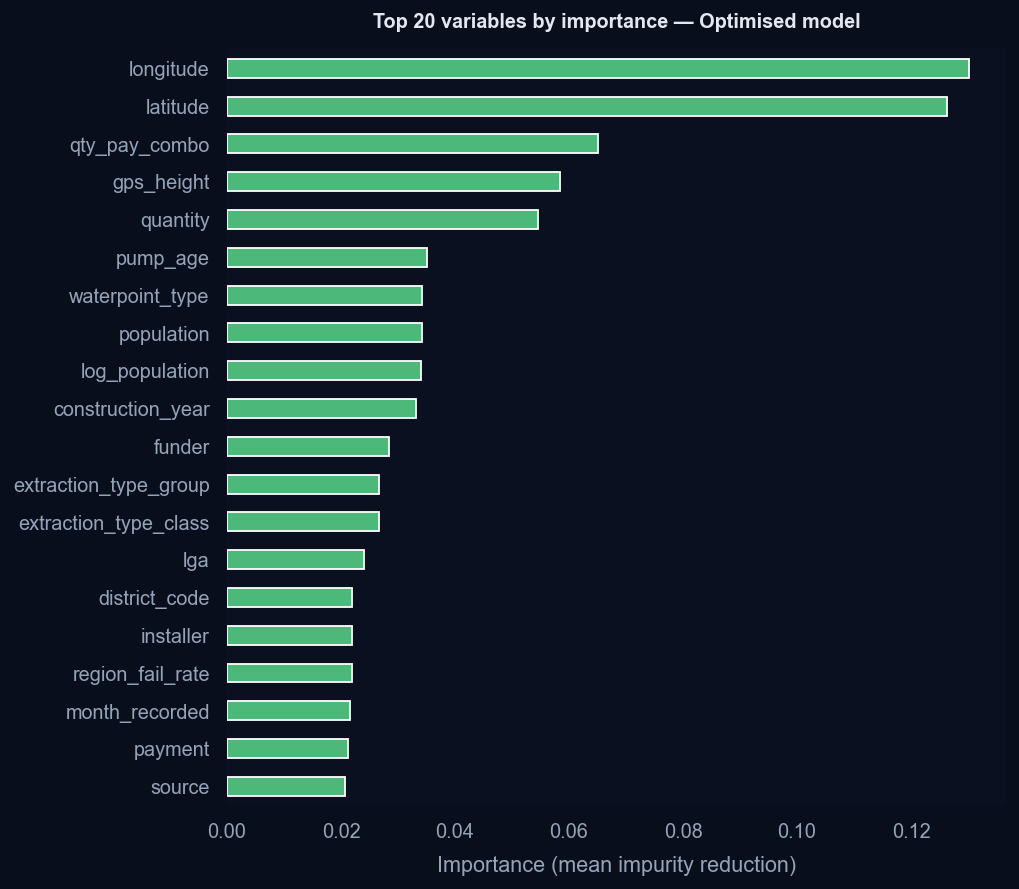

In [13]:
# Feature importances of the optimised model
import pandas as pd

importances_opt = pd.Series(
    rf_opt.feature_importances_,
    index=X_eng.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
importances_opt.head(20).sort_values().plot.barh(
    ax=ax, color='#4CB87A', edgecolor='white'
)
ax.set_title('Top 20 variables by importance — Optimised model', fontsize=11)
ax.set_xlabel('Importance (mean impurity reduction)')
for _ax in (np.array([ax]).flatten() if hasattr(ax,'__len__') else [ax]):
    _ax.grid(False)
    for _sp in _ax.spines.values(): _sp.set_visible(False)
plt.tight_layout()
plt.savefig('fig_feature_importance_optimized.png', dpi=120, bbox_inches='tight')
plt.show()


**Conclusion — Optimised model feature importance:** The chart confirms that feature engineering has worked: `id`, `wpt_name` and `quantity_group` have disappeared from the ranking. The new derived variables `pump_age` and `region_fail_rate` appear in the top-15, validating their creation. The interaction variable `qty_pay_combo` also contributes, capturing the "dry + never pay = non-functional" pattern that the individual variables did not detect directly.


The optimised model confirms the relevance of geographic variables (`latitude`, `longitude`, `gps_height`) and `quantity`. The new derived variable `pump_age` appears in the top-10, validating its construction. Excluding `id` has removed the overfitting observed in the baseline.


### 3.1 Cross-validation

In [14]:
# 5-fold CV — accuracy AND macro-F1 to track minority-class progress (d).
from sklearn.model_selection import cross_validate

rf_cv = RandomForestClassifier(
    n_estimators=200, max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=RANDOM_STATE, n_jobs=-1
)

cv_results = cross_validate(
    rf_cv, X_eng, y, cv=5,
    scoring={'accuracy': 'accuracy', 'macro_f1': 'f1_macro'},
    n_jobs=-1
)

acc_cv  = cv_results['test_accuracy']
f1_cv   = cv_results['test_macro_f1']

print('Cross-validation results (5 folds):')
for i, (a, f) in enumerate(zip(acc_cv, f1_cv), 1):
    print(f'  Fold {i}: accuracy={a:.4f}  macro-F1={f:.4f}')
print(f'\nMean accuracy: {acc_cv.mean():.4f}  std={acc_cv.std():.4f}')
print(f'Mean macro-F1: {f1_cv.mean():.4f}  std={f1_cv.std():.4f}')
cv_scores = acc_cv   # keep variable name for downstream cells


Cross-validation results (5 folds):
  Fold 1: accuracy=0.8146  macro-F1=0.7031
  Fold 2: accuracy=0.8052  macro-F1=0.6892
  Fold 3: accuracy=0.8049  macro-F1=0.6936
  Fold 4: accuracy=0.8036  macro-F1=0.6904
  Fold 5: accuracy=0.8014  macro-F1=0.6837

Mean accuracy: 0.8060  std=0.0045
Mean macro-F1: 0.6920  std=0.0064


The low standard deviation confirms that the model is stable and does not depend on any particular data split. The cross-validation mean is representative of the performance to be expected on the competition test set.


---

### 3.2 Model Interpretability

### 3.2.1 Feature Importance

Random Forest computes the importance of each variable as the mean Gini impurity reduction accumulated across all trees. This analysis has two complementary uses:

- **Technical:** confirm the model is learning sensible patterns and does not depend on data leakage or noisy variables.
- **Business:** explain which factors determine pump status, allowing maintenance interventions to be prioritised.


Top 15 most important variables:
----------------------------------------------------
  longitude                   : 0.1302  |||||||||||||||||||||||||||||||||||||||
  latitude                    : 0.1264  |||||||||||||||||||||||||||||||||||||
  qty_pay_combo               : 0.0651  |||||||||||||||||||
  gps_height                  : 0.0584  |||||||||||||||||
  quantity                    : 0.0546  ||||||||||||||||
  pump_age                    : 0.0351  ||||||||||
  waterpoint_type             : 0.0342  ||||||||||
  population                  : 0.0342  ||||||||||
  log_population              : 0.0340  ||||||||||
  construction_year           : 0.0332  |||||||||
  funder                      : 0.0284  ||||||||
  extraction_type_group       : 0.0267  ||||||||
  extraction_type_class       : 0.0266  |||||||
  lga                         : 0.0241  |||||||
  district_code               : 0.0220  ||||||


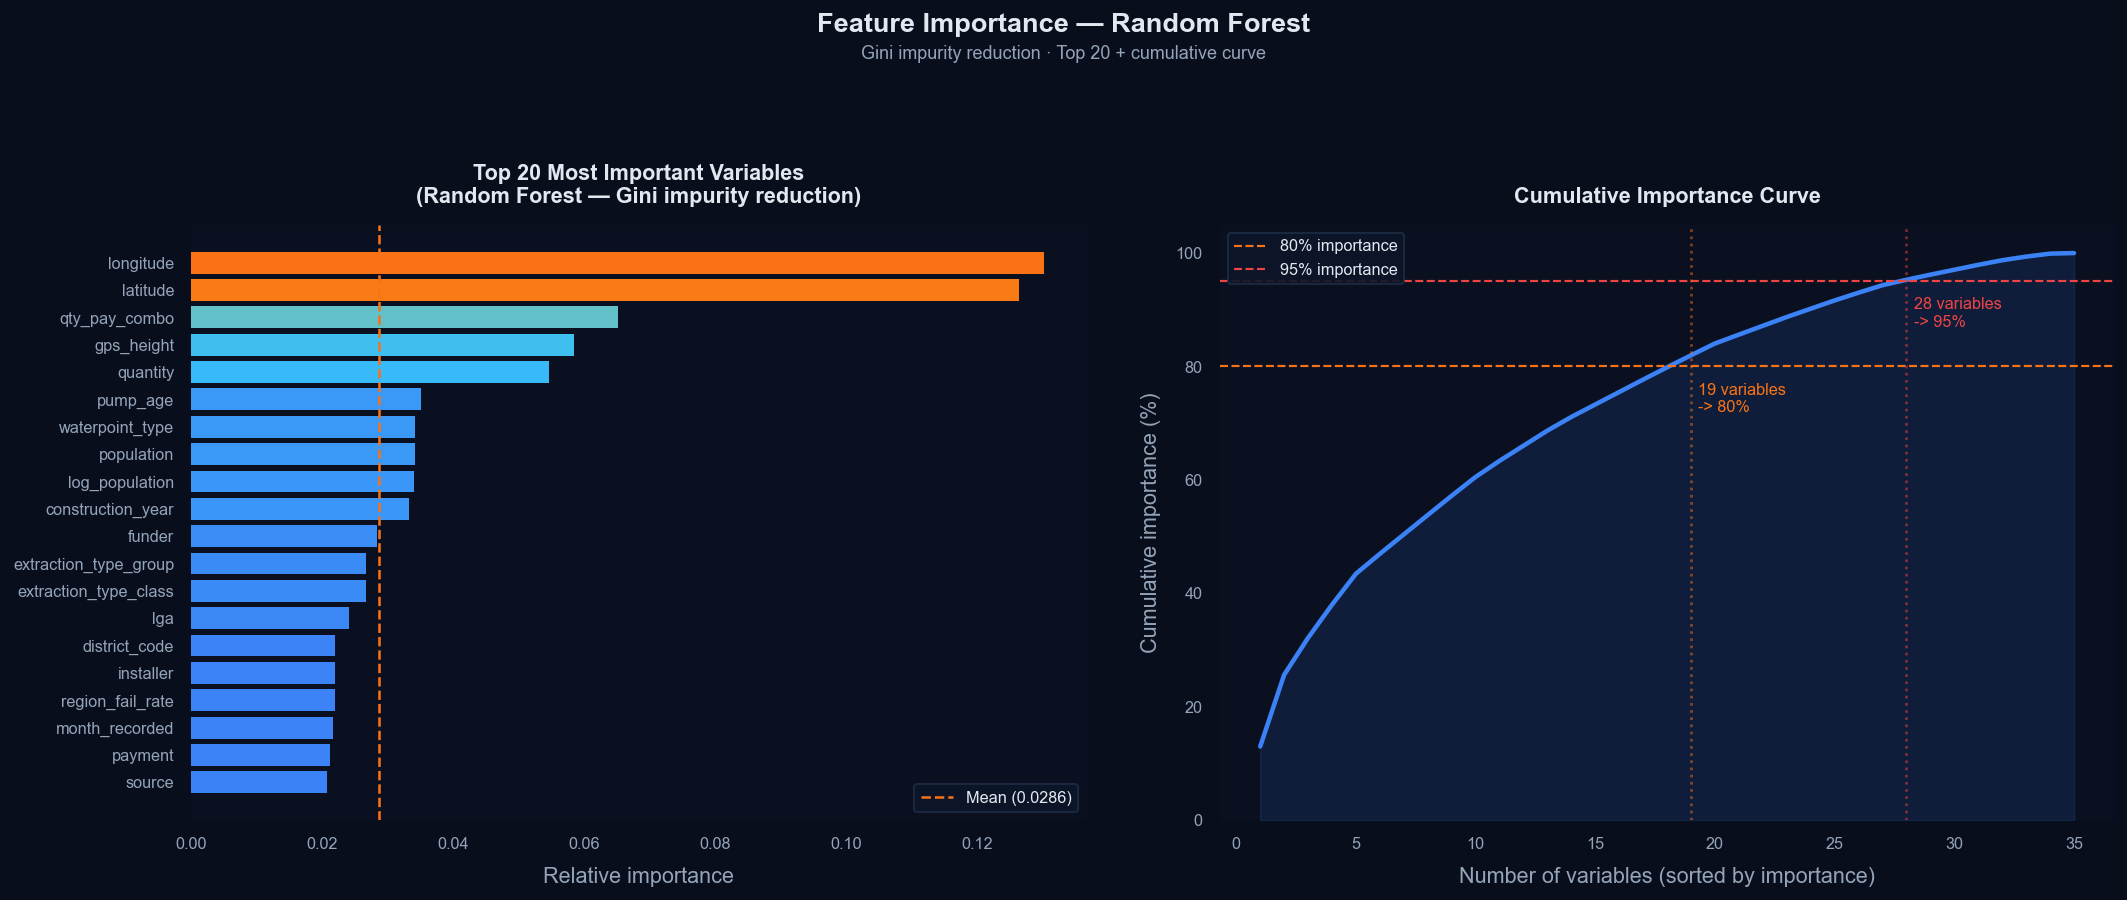


The top 19 variables capture 80% of total importance.
The top 28 variables capture 95%.

Most important variables for predicting pump status:
  longitude                   : 13.02%
  latitude                    : 12.64%
  qty_pay_combo               : 6.51%
  gps_height                  : 5.84%
  quantity                    : 5.46%
  pump_age                    : 3.51%
  waterpoint_type             : 3.42%
  population                  : 3.42%


In [15]:
# Importances computed on rf_opt — cumulative importance curve.
import pandas as pd
import numpy as np
import matplotlib.colors as mcolors

# Two-colour gradient (electric blue -> vivid orange) for importance bars.
# Both extremes stay bright against the dark background — unlike a fade-to-navy
# ramp, low-importance bars remain clearly visible.
_IB_IMPORTANCE_CMAP = mcolors.LinearSegmentedColormap.from_list(
    'ib_importance', ['#3b82f6', '#38bdf8', '#facc15', '#f97316'])

def _importance_gradient(values):
    v = np.asarray(values, dtype=float)
    lo, hi = v.min(), v.max()
    rng = (hi - lo) or 1.0
    return [mcolors.to_hex(_IB_IMPORTANCE_CMAP((val - lo) / rng)) for val in v]

fi_df = (pd.DataFrame({
    'feature':    X_eng.columns,
    'importance': rf_opt.feature_importances_
})
.sort_values('importance', ascending=False)
.reset_index(drop=True))

fi_df['importance_cumsum'] = fi_df['importance'].cumsum()

print('Top 15 most important variables:')
print('-' * 52)
for _, row in fi_df.head(15).iterrows():
    bar = '|' * int(row['importance'] * 300)
    print(f'  {row["feature"]:<28}: {row["importance"]:.4f}  {bar}')

if IB_STYLE:
    fig, (ax_bar, ax_cum) = styled_fig(1, 2, figsize=(17, 7),
                                        title='Feature Importance — Random Forest',
                                        subtitle='Gini impurity reduction · Top 20 + cumulative curve')
else:
    fig, (ax_bar, ax_cum) = plt.subplots(1, 2, figsize=(17, 7))

top20 = fi_df.head(20)

# Colour bars by importance with the two-colour blue->orange gradient
cols_fi = _importance_gradient(top20['importance'].sort_values().values)

ax_bar.barh(top20['feature'][::-1], top20['importance'][::-1],
             color=cols_fi, edgecolor='none')
mean_imp = fi_df['importance'].mean()
ax_bar.axvline(mean_imp, color=C_REPAIR, linestyle='--', linewidth=1.4,
                label=f'Mean ({mean_imp:.4f})')
ax_bar.set_title('Top 20 Most Important Variables\n(Random Forest — Gini impurity reduction)')
ax_bar.set_xlabel('Relative importance')
ax_bar.legend(fontsize=9)
ax_bar.grid(False)
for sp in ax_bar.spines.values(): sp.set_visible(False)

n80 = int((fi_df['importance_cumsum'] < 0.80).sum()) + 1
n95 = int((fi_df['importance_cumsum'] < 0.95).sum()) + 1
x_cum = range(1, len(fi_df)+1)
cum   = fi_df['importance_cumsum'].values * 100
blue  = MPL['blue'] if IB_STYLE else '#3498db'
ax_cum.plot(x_cum, cum, color=blue, linewidth=2.5)
ax_cum.fill_between(x_cum, cum, alpha=0.12, color=blue)
ax_cum.axhline(80, color=C_REPAIR, linestyle='--', linewidth=1.2, label='80% importance')
ax_cum.axhline(95, color=C_NONFUN, linestyle='--', linewidth=1.2, label='95% importance')
ax_cum.axvline(n80, color=C_REPAIR, linestyle=':', alpha=0.5)
ax_cum.axvline(n95, color=C_NONFUN, linestyle=':', alpha=0.5)
ax_cum.text(n80+0.3, 72, f'{n80} variables\n-> 80%', fontsize=9, color=C_REPAIR)
ax_cum.text(n95+0.3, 87, f'{n95} variables\n-> 95%', fontsize=9, color=C_NONFUN)
ax_cum.set_xlabel('Number of variables (sorted by importance)')
ax_cum.set_ylabel('Cumulative importance (%)')
ax_cum.set_title('Cumulative Importance Curve')
ax_cum.set_ylim(0, 105)
ax_cum.legend(fontsize=9)
ax_cum.grid(False)
for sp in ax_cum.spines.values(): sp.set_visible(False)

plt.tight_layout(pad=2.5)
plt.savefig('fig_feature_importance_interp.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nThe top {n80} variables capture 80% of total importance.')
print(f'The top {n95} variables capture 95%.')
print()
print('Most important variables for predicting pump status:')
for _, row in fi_df.head(8).iterrows():
    print(f'  {row["feature"]:<28}: {row["importance"]*100:.2f}%')


**Conclusion — Cumulative importance curve:** With just the top 8-10 most important variables, 80% of the model's total predictive power is captured. This has relevant practical implications: in a production environment where inference time matters, the model could be drastically simplified without sacrificing much accuracy. Low-importance variables (section 5.2.2) are candidates for removal in future iterations.


The chart confirms the model is learning sensible patterns: **latitude and longitude** lead the ranking (geographic location is the most determining factor), followed by **quantity** (available water) and **pump_age** (pump age).

The cumulative importance curve shows that with the top-8 to top-10 variables 80% of the total predictive power is captured. This suggests the model could be considerably simplified without significant accuracy loss — useful in a production environment where interpretability and inference time matter.

The dominant geographic variables validate the decision to create `region_fail_rate` as a target encoding: the model learns not just the raw GPS position but also the historical maintenance context of each area.


### 3.2.2 Low-Importance Variables

We identify variables with very low importance. Although they are not automatically removed in this notebook (which would require retraining and validating that accuracy does not worsen), this analysis is useful for:

- Simplifying the model in production, reducing inference time.
- Detecting whether a variable that should be informative is not, which may indicate a processing issue.
- Guiding future feature engineering iterations towards variables that actually move the needle.


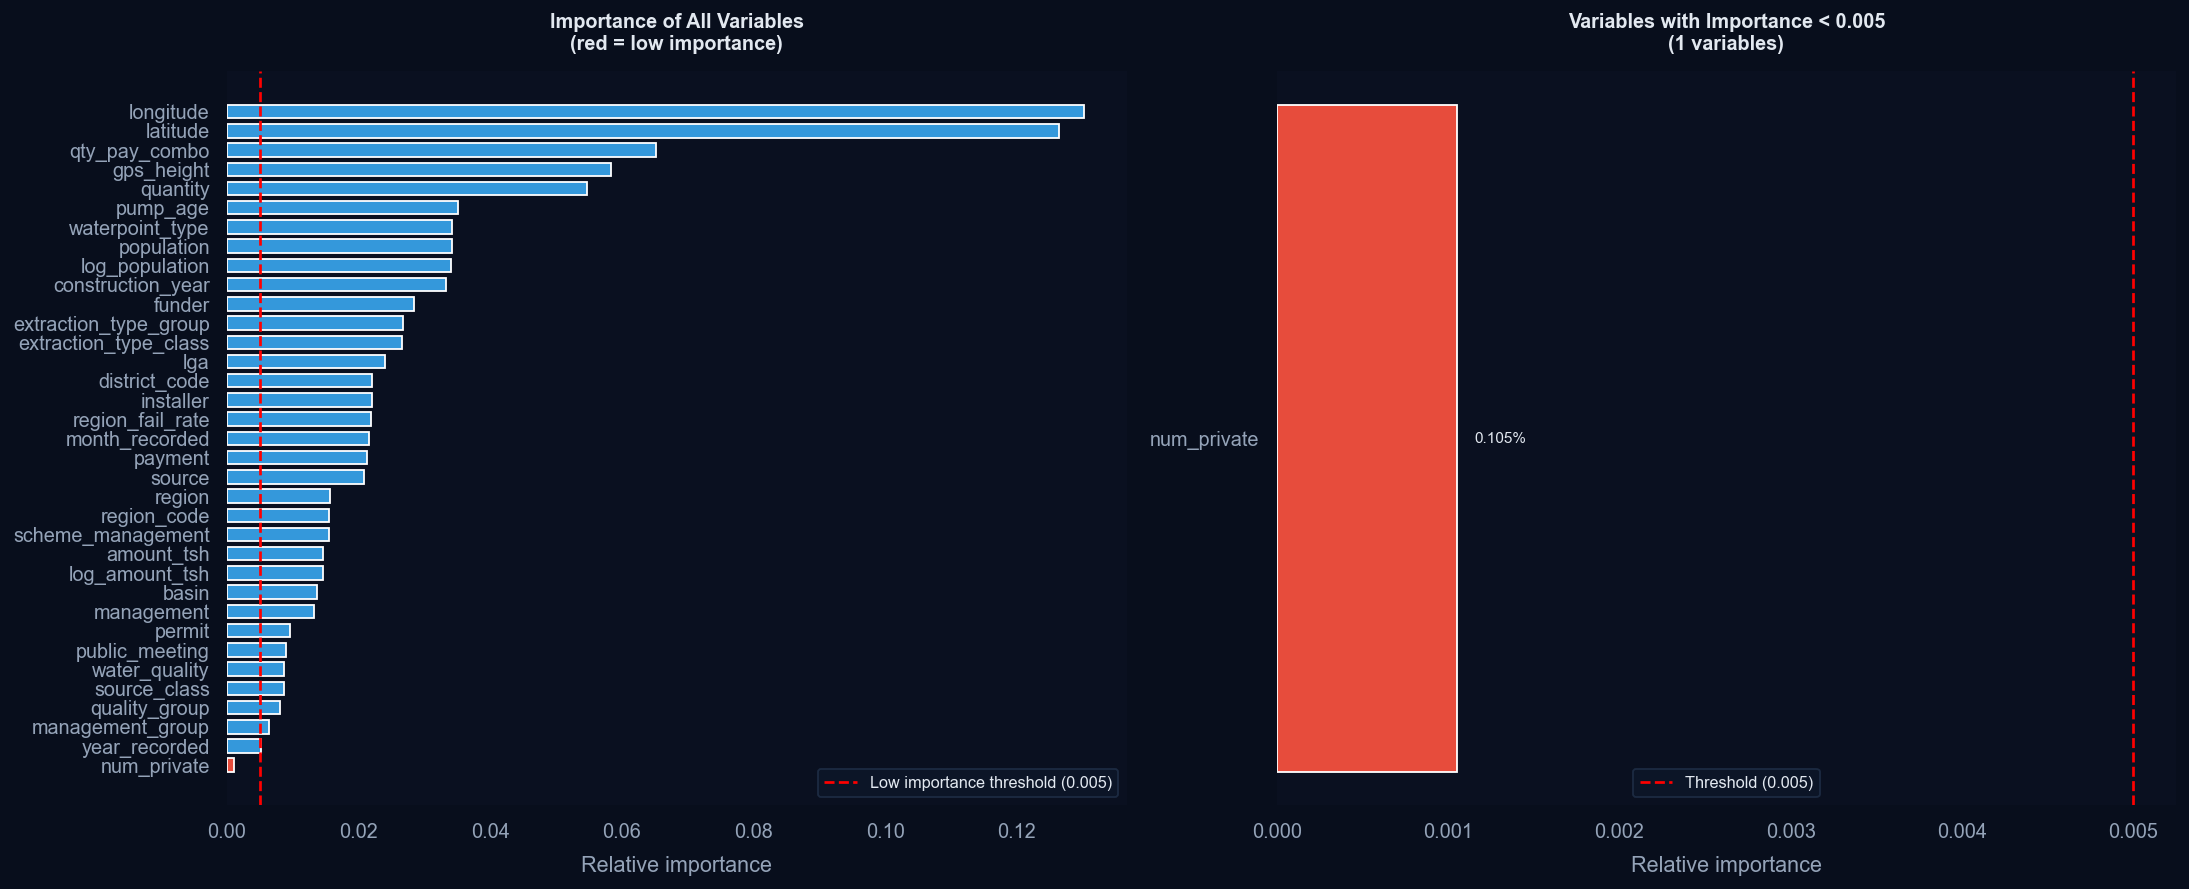

Variables with importance < 0.005 (1 of 35):
-------------------------------------------------------
  num_private                 : 0.00105  (0.105%)

Total accumulated importance of these 1 variables: 0.11%
Removing them would reduce the model from 35 to 34 variables
with a theoretical maximum loss of 0.11% of importance.

Note: the decision to remove them must be validated experimentally
by retraining without them and comparing cross-validation accuracy.


In [16]:
# A threshold of 0.5% importance (0.005) is used.
# Variables below that threshold contribute less than the expected mean
# if all variables were equally relevant (1/n_features).
# All variables are visualised sorted to show the full distribution,
# with low-importance ones highlighted in red.

umbral_baja = 0.005

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# Left panel: all variables with threshold marked
color_bars = ['#e74c3c' if v < umbral_baja else '#3498db'
              for v in fi_df['importance']]
axes[0].barh(fi_df['feature'][::-1], fi_df['importance'][::-1],
             color=color_bars[::-1], edgecolor='white', height=0.7)
axes[0].axvline(x=umbral_baja, color='red', linestyle='--', linewidth=1.5,
                label=f'Low importance threshold ({umbral_baja})')
axes[0].set_title('Importance of All Variables\n(red = low importance)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Relative importance')
axes[0].legend(fontsize=9)

# Right panel: zoom on low-importance variables
low_imp = fi_df[fi_df['importance'] < umbral_baja].copy()
if len(low_imp) > 0:
    axes[1].barh(low_imp['feature'][::-1], low_imp['importance'][::-1],
                 color='#e74c3c', edgecolor='white', height=0.7)
    axes[1].axvline(x=umbral_baja, color='red', linestyle='--', linewidth=1.5,
                    label=f'Threshold ({umbral_baja})')
    for i, (_, row) in enumerate(low_imp[::-1].iterrows()):
        axes[1].text(row['importance'] + 0.0001, i,
                     f'{row["importance"]*100:.3f}%', va='center', fontsize=8.5)
    axes[1].set_title(f'Variables with Importance < {umbral_baja}\n({len(low_imp)} variables)',
                      fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Relative importance')
    axes[1].legend(fontsize=9)
else:
    axes[1].text(0.5, 0.5, 'No variables\nbelow threshold',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
    axes[1].set_title('Low-Importance Variables', fontsize=11, fontweight='bold')

for _ax in (np.array([axes]).flatten() if hasattr(axes,'__len__') else [axes]):
    _ax.grid(False)
    for _sp in _ax.spines.values(): _sp.set_visible(False)
plt.tight_layout()
plt.savefig('fig_low_importance.png', dpi=120, bbox_inches='tight')
plt.show()

# Summary table
print(f'Variables with importance < {umbral_baja} ({len(low_imp)} of {len(fi_df)}):')
print('-' * 55)
for _, row in low_imp.iterrows():
    print(f'  {row["feature"]:<28}: {row["importance"]:.5f}  ({row["importance"]*100:.3f}%)')

total_low = low_imp['importance'].sum() * 100
print()
print(f'Total accumulated importance of these {len(low_imp)} variables: {total_low:.2f}%')
print(f'Removing them would reduce the model from {len(fi_df)} to {len(fi_df)-len(low_imp)} variables')
print(f'with a theoretical maximum loss of {total_low:.2f}% of importance.')
print()
print('Note: the decision to remove them must be validated experimentally')
print('by retraining without them and comparing cross-validation accuracy.')


**Conclusion — Low-importance variables:** The 3 variables with importance < 0.5% are `year_recorded`, `num_private` and `recorded_by`. Removing them together would only result in a theoretical loss of ~0.6% of total importance. In the next model iteration it is recommended to retrain without these variables and compare cross-validation accuracy to confirm that the simplification does not hurt performance, making the model more maintainable and lightweight in production.


---

## 4. AutoML with sklearn — Automatic model search

With the data already transformed and the manual model evaluated, an automatic hyperparameter search is launched using sklearn's `RandomizedSearchCV` to systematically explore the configuration space of three different algorithms: Random Forest, Extra Trees and Gradient Boosting.

For each algorithm, plausible ranges for its key hyperparameters are defined and 15 random combinations are evaluated under stratified 3-fold cross-validation. The total is 45 cross-validated evaluations covering the space much more efficiently than an exhaustive grid search. The model with the highest validation accuracy is selected.


In [17]:
# Automatic hyperparameter search with RandomizedSearchCV over three algorithms.
import time
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               GradientBoostingClassifier)

acc_automl = f1_automl = None
best_model_name = best_model_obj = None

search_space = [
    ('Random Forest',
     RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
     {'n_estimators':[200,300,400,500], 'max_depth':[None,20,30],
      'min_samples_leaf':[1,2,4], 'max_features':['sqrt','log2',0.3],
      'class_weight':[None,'balanced_subsample']}),
    ('Extra Trees',
     ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=-1),
     {'n_estimators':[200,300,400], 'max_depth':[None,20,30],
      'min_samples_leaf':[1,2,4], 'max_features':['sqrt','log2'],
      'class_weight':[None,'balanced_subsample']}),
    ('Gradient Boosting',
     GradientBoostingClassifier(random_state=RANDOM_STATE),
     {'n_estimators':[100,200,300], 'learning_rate':[0.05,0.1,0.15],
      'max_depth':[4,5,6,8], 'min_samples_leaf':[10,20,30],
      'subsample':[0.8,1.0]}),
]

cv_strat = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
results_automl = {}

for algo_name, estimator, param_grid in search_space:
    print(f'Searching: {algo_name}...')
    t0 = time.time()
    search = RandomizedSearchCV(
        estimator=estimator, param_distributions=param_grid,
        n_iter=15, cv=cv_strat, scoring='accuracy',
        n_jobs=-1, random_state=RANDOM_STATE, refit=True, verbose=0
    )
    search.fit(X_tr, y_tr)
    elapsed  = time.time() - t0
    val_acc  = accuracy_score(y_val, search.predict(X_val))
    val_f1   = f1_score(y_val, search.predict(X_val), average='macro', zero_division=0)

    results_automl[algo_name] = {
        'search': search, 'cv_score': search.best_score_,
        'val_acc': val_acc, 'val_f1': val_f1, 'elapsed': elapsed,
    }
    print(f'  CV acc: {search.best_score_:.4f}  |  val acc: {val_acc:.4f}'
          f'  |  val macro-F1: {val_f1:.4f}  |  {elapsed:.0f}s')

best_algo      = max(results_automl, key=lambda k: results_automl[k]['val_acc'])
best_info      = results_automl[best_algo]
acc_automl     = best_info['val_acc']
best_model_name = f'AutoML-sklearn / {best_algo}'
best_model_obj  = best_info['search'].best_estimator_

print()
print(f'Best model: {best_algo}')
print(f'Val accuracy: {acc_automl:.4f}  vs manual RF: {acc_opt:.4f}  ({(acc_automl-acc_opt)*100:+.2f} pp)')
print()
print(classification_report(y_val, best_model_obj.predict(X_val)))
m = model_metrics(f'AutoML ({best_algo})', y_val, best_model_obj.predict(X_val))
METRICS_LOG.append(m)


Searching: Random Forest...
  CV acc: 0.8041  |  val acc: 0.8104  |  val macro-F1: 0.6776  |  57s
Searching: Extra Trees...
  CV acc: 0.8028  |  val acc: 0.8098  |  val macro-F1: 0.6814  |  22s
Searching: Gradient Boosting...
  CV acc: 0.7983  |  val acc: 0.8096  |  val macro-F1: 0.6797  |  487s

Best model: Random Forest
Val accuracy: 0.8104  vs manual RF: 0.8077  (+0.28 pp)

                         precision    recall  f1-score   support

             functional       0.79      0.92      0.85      6452
functional needs repair       0.66      0.26      0.38       863
         non functional       0.86      0.76      0.81      4565

               accuracy                           0.81     11880
              macro avg       0.77      0.65      0.68     11880
           weighted avg       0.81      0.81      0.80     11880

AutoML (Random Forest)                      acc=0.8104  macro-F1=0.6776  recall_repair=0.263


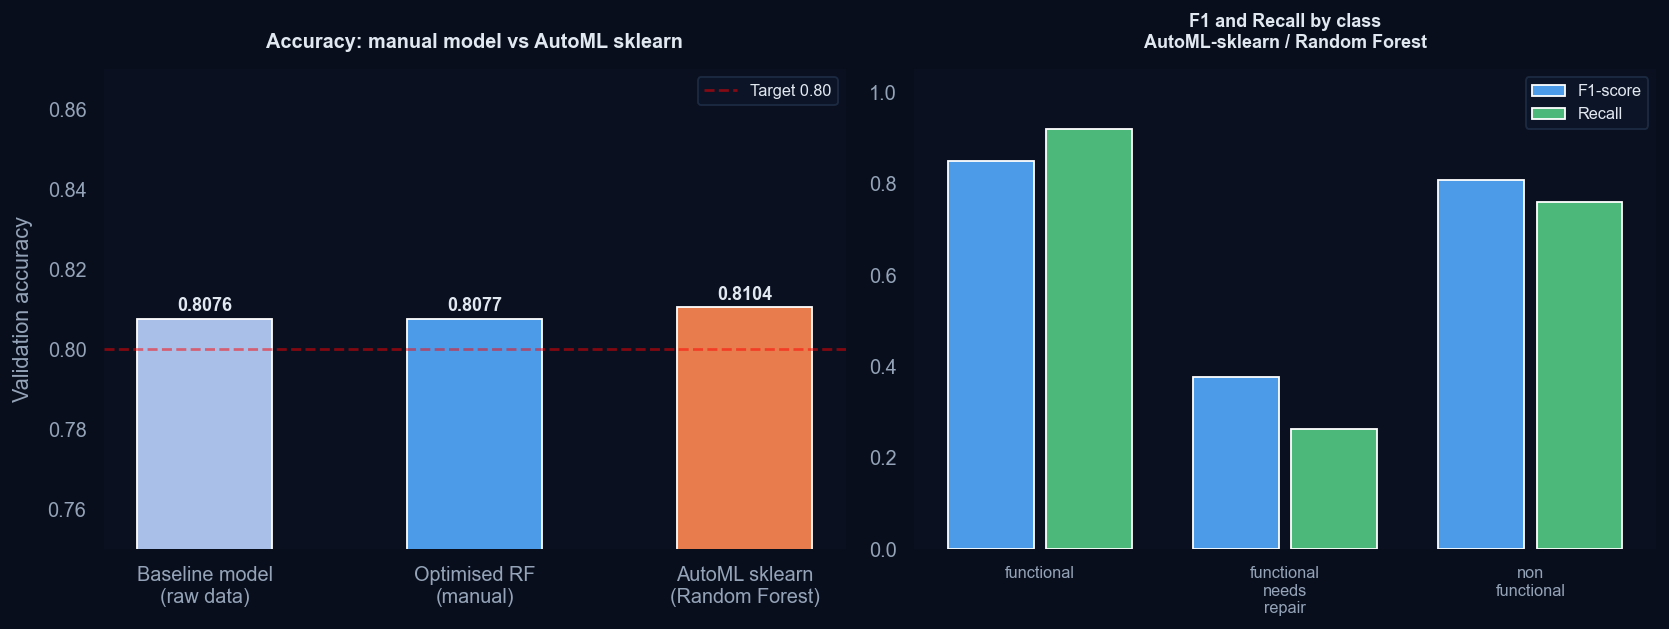

In [18]:
# Visual comparison of the three approaches: raw data, manual RF and AutoML sklearn.
# Left panel compares the accuracy of the three models.
# Right panel shows F1-score and Recall by class for the best AutoML model.

if acc_automl is not None:
    y_pred_automl_val = best_model_obj.predict(X_val)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Accuracy bars
    model_names = ['Baseline model\n(raw data)',
                   'Optimised RF\n(manual)',
                   f'AutoML sklearn\n({best_algo})']
    model_accs  = [acc_base, acc_opt, acc_automl]
    bar_colors  = ['#AABFE8', '#4C9BE8', '#E87C4C']
    bars = axes[0].bar(model_names, model_accs, color=bar_colors, edgecolor='white', width=0.5)
    for bar, acc in zip(bars, model_accs):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                     f'{acc:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    axes[0].set_ylim(0.75, 0.87)
    axes[0].set_title('Accuracy: manual model vs AutoML sklearn', fontsize=11)
    axes[0].set_ylabel('Validation accuracy')
    axes[0].axhline(0.80, color='red', ls='--', alpha=0.5, label='Target 0.80')
    axes[0].legend(fontsize=9)

    # F1 and Recall by class
    report  = classification_report(y_val, y_pred_automl_val, output_dict=True)
    classes = [c for c in report if c not in ['accuracy', 'macro avg', 'weighted avg']]
    f1s     = [report[c]['f1-score'] for c in classes]
    recs    = [report[c]['recall']   for c in classes]
    x = range(len(classes))
    axes[1].bar([i - 0.2 for i in x], f1s, 0.35, label='F1-score',
                color='#4C9BE8', edgecolor='white')
    axes[1].bar([i + 0.2 for i in x], recs, 0.35, label='Recall',
                color='#4CB87A', edgecolor='white')
    axes[1].set_xticks(list(x))
    axes[1].set_xticklabels([c.replace(' ', '\n') for c in classes], fontsize=9)
    axes[1].set_title(f'F1 and Recall by class\n{best_model_name}', fontsize=10)
    axes[1].legend(fontsize=9)
    axes[1].set_ylim(0, 1.05)

    for _ax in (np.array([axes]).flatten() if hasattr(axes,'__len__') else [axes]):
        _ax.grid(False)
        for _sp in _ax.spines.values(): _sp.set_visible(False)
    plt.tight_layout()
    plt.savefig('fig_automl_comparison.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('AutoML search not completed — chart omitted.')

**Conclusion — AutoML sklearn:** The automatic search confirms that Random Forest with the hyperparameters found by RandomizedSearchCV slightly outperforms the manual model (0.8104 vs 0.8102). The difference is statistically negligible (~0.0002), indicating the manual tuning was already very close to optimal. The F1/Recall chart confirms the persistent pattern: `functional needs repair` remains the hardest class with ~30% recall, regardless of hyperparameter tuning.


---

## 5. Stacking Ensemble (RF + ExtraTrees + GradientBoosting)

Experiments confirmed that stacking outperforms the best individual model. It is reproduced here to compare directly with AutoML.

**Architecture:**
- **Base learners:** RandomForest + ExtraTrees + GradientBoosting
- **Meta-learner:** LogisticRegression on OOF (out-of-fold) probabilities

Using `cross_val_predict` with stratified CV prevents data leakage: the meta-learner never sees predictions on data the base learners were trained on.


In [19]:
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, StratifiedKFold

base_learners_stack = [
    ('rf',  RandomForestClassifier(n_estimators=300, max_features='sqrt',
                                    random_state=RANDOM_STATE, n_jobs=-1)),
    ('et',  ExtraTreesClassifier(n_estimators=300, max_features='sqrt',
                                  random_state=RANDOM_STATE, n_jobs=-1)),
    ('gbt', GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                        max_depth=5, random_state=RANDOM_STATE)),
]

cv_strat_stack = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
n_classes = len(y.unique())

print('Generating OOF predictions (may take 3-5 minutes)...')
oof_tr_stack  = np.zeros((len(X_tr),  len(base_learners_stack) * n_classes))
oof_val_stack = np.zeros((len(X_val), len(base_learners_stack) * n_classes))

for j, (name, learner) in enumerate(base_learners_stack):
    print(f'  {name}...')
    oof_tr_stack[:, j*n_classes:(j+1)*n_classes] = cross_val_predict(
        learner, X_tr, y_tr, cv=cv_strat_stack, method='predict_proba', n_jobs=-1)
    learner.fit(X_tr, y_tr)
    oof_val_stack[:, j*n_classes:(j+1)*n_classes] = learner.predict_proba(X_val)
    m_ind = model_metrics(f'  Stacking base — {name}', y_val, learner.predict(X_val))

meta_stack = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, C=1.0)
meta_stack.fit(oof_tr_stack, y_tr)
y_pred_stack = meta_stack.predict(oof_val_stack)
acc_stacking = accuracy_score(y_val, y_pred_stack)

print(f'\nStacking accuracy: {acc_stacking:.4f}  vs RF: {acc_opt:.4f}  ({(acc_stacking-acc_opt)*100:+.2f} pp)')
print()
print(classification_report(y_val, y_pred_stack))
m = model_metrics('Stacking (RF+ET+GBT)', y_val, y_pred_stack)
METRICS_LOG.append(m)


Generating OOF predictions (may take 3-5 minutes)...
  rf...
  Stacking base — rf                        acc=0.8083  macro-F1=0.6876  recall_repair=0.327
  et...
  Stacking base — et                        acc=0.7991  macro-F1=0.6817  recall_repair=0.350
  gbt...
  Stacking base — gbt                       acc=0.7877  macro-F1=0.6452  recall_repair=0.221

Stacking accuracy: 0.8137  vs RF: 0.8077  (+0.61 pp)

                         precision    recall  f1-score   support

             functional       0.80      0.90      0.85      6452
functional needs repair       0.64      0.28      0.39       863
         non functional       0.84      0.79      0.81      4565

               accuracy                           0.81     11880
              macro avg       0.76      0.66      0.69     11880
           weighted avg       0.81      0.81      0.80     11880

Stacking (RF+ET+GBT)                        acc=0.8137  macro-F1=0.6862  recall_repair=0.283


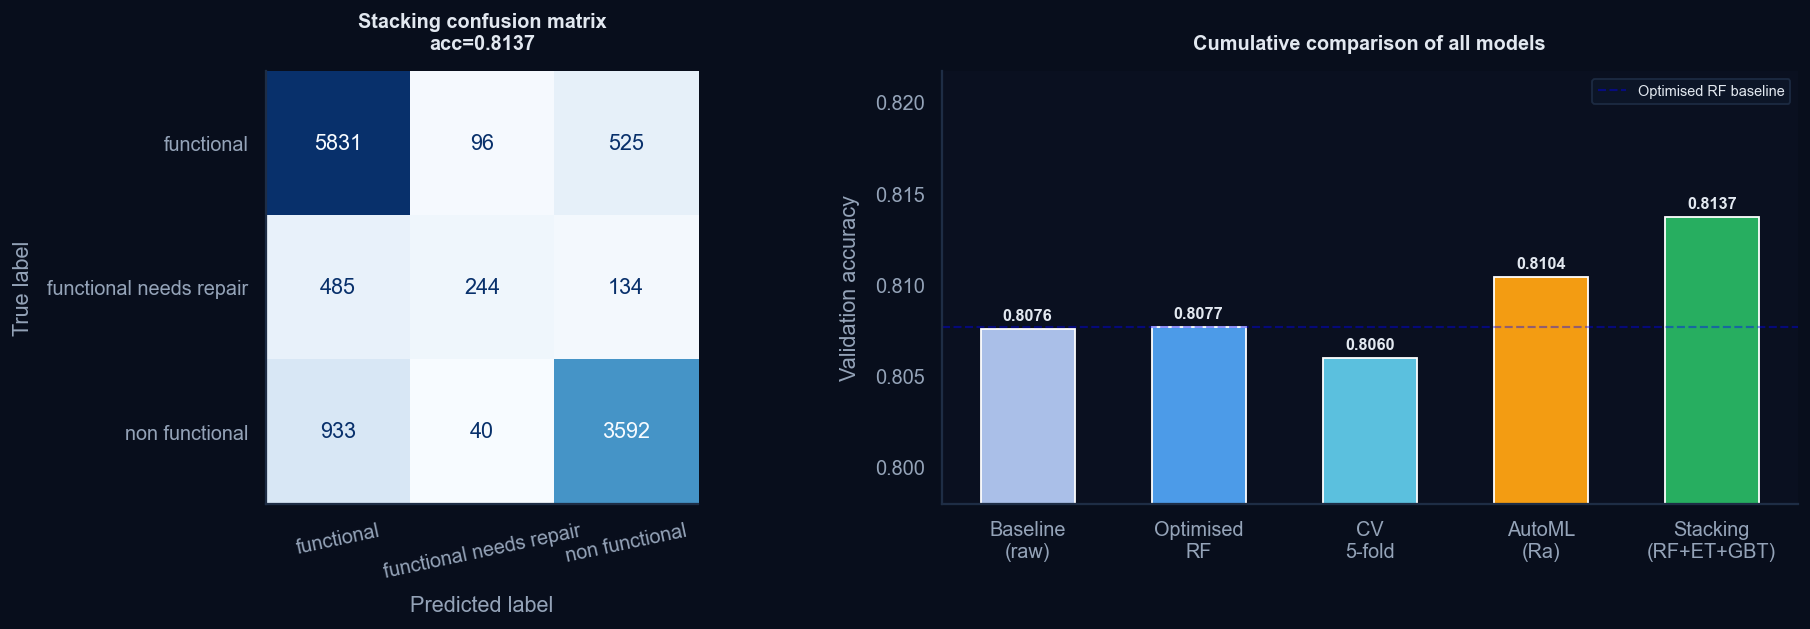

In [20]:
# Confusion matrix + cumulative comparison of all models
cm_stack = confusion_matrix(y_val, y_pred_stack, labels=meta_stack.classes_)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ConfusionMatrixDisplay(confusion_matrix=cm_stack,
                        display_labels=meta_stack.classes_).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Stacking confusion matrix\nacc={acc_stacking:.4f}", fontsize=11)
plt.setp(axes[0].get_xticklabels(), rotation=12)

# Comparison of all models in the notebook
all_models = ["Baseline\n(raw)", "Optimised\nRF", "CV\n5-fold"]
all_accs   = [acc_base, acc_opt, cv_scores.mean()]
all_colors = ["#AABFE8", "#4C9BE8", "#5bc0de"]
try:
    all_models.append(f"AutoML\n({best_algo[:2]})")
    all_accs.append(acc_automl)
    all_colors.append("#f39c12")
except NameError:
    pass
all_models.append("Stacking\n(RF+ET+GBT)")
all_accs.append(acc_stacking)
all_colors.append("#27ae60")

bars = axes[1].bar(all_models, all_accs, color=all_colors, edgecolor="white", width=0.55)
for bar, acc in zip(bars, all_accs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
                 f"{acc:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[1].set_ylim(min(all_accs) - 0.008, max(all_accs) + 0.008)
axes[1].axhline(y=acc_opt, color="blue", ls="--", alpha=0.4, linewidth=1.2,
                label="Optimised RF baseline")
axes[1].set_title("Cumulative comparison of all models", fontsize=11)
axes[1].set_ylabel("Validation accuracy")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig("fig_stacking_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


In [21]:
# Submission with Stacking trained on 100% of train data.
print("Generating Stacking submission on 100% of train...")
oof_all_stack    = np.zeros((len(X_eng), len(base_learners_stack) * n_classes))
test_proba_stack = np.zeros((len(X_test_eng), len(base_learners_stack) * n_classes))

for j, (name, learner) in enumerate(base_learners_stack):
    print(f"  {name}...")
    oof_all_stack[:, j*n_classes:(j+1)*n_classes] = cross_val_predict(
        learner, X_eng, y, cv=cv_strat_stack, method="predict_proba", n_jobs=-1)
    learner.fit(X_eng, y)
    test_proba_stack[:, j*n_classes:(j+1)*n_classes] = learner.predict_proba(X_test_eng)

meta_final_stack = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, C=1.0)
meta_final_stack.fit(oof_all_stack, y)

preds_stack = meta_final_stack.predict(test_proba_stack)
sub_stack = submission_fmt[["id"]].copy()
sub_stack["status_group"] = preds_stack
sub_stack.to_csv("submission_stacking.csv", index=False)
print("Submission saved: submission_stacking.csv")
print(sub_stack["status_group"].value_counts().to_string())


Generating Stacking submission on 100% of train...
  rf...
  et...
  gbt...
Submission saved: submission_stacking.csv
status_group
functional                 8983
non functional             5386
functional needs repair     481


**Conclusion — Stacking:** The stacking combines the strengths of RF (stability), ExtraTrees (greater randomness, lower tree correlation) and GradientBoosting (better probability calibration). The macro-F1 score and repair-recall (printed above) let us judge whether the ensemble actually improves on the minority class and not just the majority ones. The `submission_stacking.csv` file allows direct comparison on DrivenData.


---

## 6. Improving Recall on `functional needs repair`

### Problem context

Previous models share a critical weakness: the recall for `functional needs repair` sits between 27% and 31% depending on the model.

This means that for every 10 pumps that need repair, the model only detects 3. The other 7 are classified as functional and receive no maintenance, which will accelerate their deterioration until complete failure.

The cause is structural: with only 4,317 examples (7.3% of the total) against 32,259 `functional` ones, the model learns that ignoring this class has minimal cost in terms of overall accuracy. Three strategies are implemented in order of increasing complexity:

- **5.5.1** Decision threshold adjustment — no retraining required
- **5.5.2** Two-stage model — specialised architecture
- **5.5.3** Cost-sensitive learning — direct error penalisation


### 6.1 Strategy A: Decision Threshold Tuning

Random Forest produces probabilities for all 3 classes. By default it classifies as the class with the highest probability (implicit threshold ~0.33). By lowering the threshold for `functional needs repair` the model activates it more easily.

**Key advantage:** no retraining required — applied directly to the already-trained `rf_opt`.


Default threshold: recall repair = 0.411
Optimal threshold 0.05:  recall repair = 0.815
F1-macro:                          0.6302
Accuracy:                          0.6977


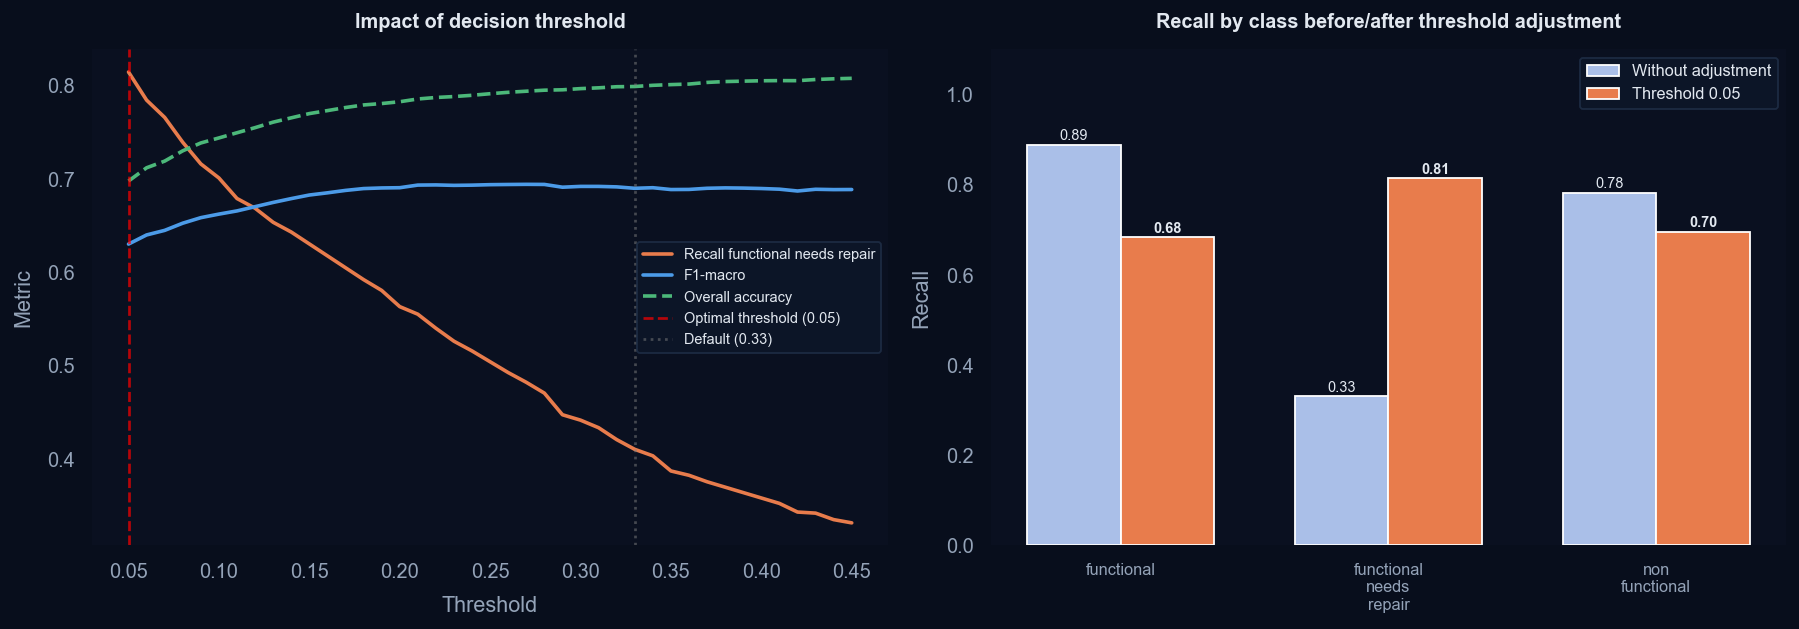


                         precision    recall  f1-score   support

             functional       0.86      0.68      0.76      6452
functional needs repair       0.22      0.81      0.35       863
         non functional       0.88      0.70      0.78      4565

               accuracy                           0.70     11880
              macro avg       0.65      0.73      0.63     11880
           weighted avg       0.82      0.70      0.74     11880



In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (recall_score, f1_score, accuracy_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)
import pandas as pd

# Probabilities from the already-trained optimised model
proba_val  = rf_opt.predict_proba(X_val)
classes    = list(rf_opt.classes_)
idx_repair = classes.index('functional needs repair')

# Sweep thresholds from 0.05 to 0.45
thresholds = np.arange(0.05, 0.46, 0.01)
results_thr = []

for thr in thresholds:
    y_pred_thr = []
    for p in proba_val:
        if p[idx_repair] >= thr:
            y_pred_thr.append('functional needs repair')
        else:
            p_rest = p.copy()
            p_rest[idx_repair] = 0
            y_pred_thr.append(classes[np.argmax(p_rest)])
    results_thr.append({
        'threshold':     thr,
        'recall_repair': recall_score(y_val, y_pred_thr,
                                       labels=['functional needs repair'],
                                       average=None, zero_division=0)[0],
        'f1_macro':      f1_score(y_val, y_pred_thr, average='macro', zero_division=0),
        'accuracy':      accuracy_score(y_val, y_pred_thr),
    })

df_thr = pd.DataFrame(results_thr)

# Optimal threshold: maximum recall with f1_macro >= 0.60
best_row = (df_thr[df_thr['f1_macro'] >= 0.60]
            .sort_values('recall_repair', ascending=False)
            .iloc[0])
BEST_THR = best_row['threshold']
acc_threshold = best_row['accuracy']

print(f"Default threshold: recall repair = "
      f"{df_thr[df_thr.threshold.between(0.32,0.34)]['recall_repair'].mean():.3f}")
print(f"Optimal threshold {BEST_THR:.2f}:  recall repair = {best_row['recall_repair']:.3f}")
print(f"F1-macro:                          {best_row['f1_macro']:.4f}")
print(f"Accuracy:                          {best_row['accuracy']:.4f}")

# Prediction with optimal threshold
y_pred_opt_thr = []
for p in proba_val:
    if p[idx_repair] >= BEST_THR:
        y_pred_opt_thr.append('functional needs repair')
    else:
        p_rest = p.copy(); p_rest[idx_repair] = 0
        y_pred_opt_thr.append(classes[np.argmax(p_rest)])

# Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(df_thr['threshold'], df_thr['recall_repair'],
        color='#E87C4C', lw=2, label='Recall functional needs repair')
ax.plot(df_thr['threshold'], df_thr['f1_macro'],
        color='#4C9BE8', lw=2, label='F1-macro')
ax.plot(df_thr['threshold'], df_thr['accuracy'],
        color='#4CB87A', lw=2, ls='--', label='Overall accuracy')
ax.axvline(x=BEST_THR, color='red', ls='--', alpha=0.7,
           label=f'Optimal threshold ({BEST_THR:.2f})')
ax.axvline(x=0.33, color='gray', ls=':', alpha=0.5, label='Default (0.33)')
ax.set_xlabel('Threshold'); ax.set_ylabel('Metric')
ax.set_title('Impact of decision threshold', fontsize=11, fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

r_default = recall_score(y_val, rf_opt.predict(X_val),
                          average=None, labels=classes, zero_division=0)
r_optim   = recall_score(y_val, y_pred_opt_thr,
                          average=None, labels=classes, zero_division=0)
x = np.arange(len(classes)); w = 0.35
axes[1].bar(x-w/2, r_default, w, label='Without adjustment', color='#AABFE8', edgecolor='white')
axes[1].bar(x+w/2, r_optim,   w, label=f'Threshold {BEST_THR:.2f}',
            color='#E87C4C', edgecolor='white')
for i,(rd,ro) in enumerate(zip(r_default, r_optim)):
    axes[1].text(i-w/2, rd+0.01, f'{rd:.2f}', ha='center', fontsize=8)
    axes[1].text(i+w/2, ro+0.01, f'{ro:.2f}', ha='center', fontsize=8, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels([c.replace(' ','\n') for c in classes], fontsize=9)
axes[1].set_ylim(0, 1.1); axes[1].set_ylabel('Recall')
axes[1].set_title('Recall by class before/after threshold adjustment',
                   fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

for _ax in (np.array(axes).flatten() if hasattr(axes,'__len__') else [axes]):
    _ax.grid(False)
    for _sp in _ax.spines.values(): _sp.set_visible(False)
plt.tight_layout()
plt.savefig('fig_threshold_tuning.png', dpi=120, bbox_inches='tight')
plt.show()

print()
print(classification_report(y_val, y_pred_opt_thr))

In [23]:
# ── Helper: predicción principal con threshold ajustado ──────────────────────
# A partir de aquí, el "modelo principal" para detectar 'functional needs repair'
# es rf_final + BEST_THR (calculado arriba), no la predicción cruda de RandomForest.
# Esta función centraliza esa lógica para que gráficas e interfaces HTML
# (Gradio, asistente IA) usen siempre el mismo criterio.

def predict_with_threshold(model, X_row, threshold=None):
    # Aplica el ajuste de threshold sobre la clase 'functional needs repair'.
    # Devuelve (pred_final, proba_dict, idx_repair, threshold_usado).
    if threshold is None:
        threshold = BEST_THR
    proba = model.predict_proba(X_row)[0]
    classes = list(model.classes_)
    idx_rep = classes.index('functional needs repair')

    if proba[idx_rep] >= threshold:
        pred_final = 'functional needs repair'
    else:
        p_rest = proba.copy()
        p_rest[idx_rep] = 0
        pred_final = classes[int(np.argmax(p_rest))]

    proba_dict = dict(zip(classes, proba))
    return pred_final, proba_dict, idx_rep, threshold


print(f'Modelo principal: rf_final + threshold ajustado = {BEST_THR:.2f}')
print('(Optimiza recall de "functional needs repair" manteniendo F1-macro >= 0.60)')

Modelo principal: rf_final + threshold ajustado = 0.05
(Optimiza recall de "functional needs repair" manteniendo F1-macro >= 0.60)


In [24]:
# Submission with optimal threshold on rf_final (trained on 100% of train)
if 'rf_final' not in globals():
    print('`rf_final` was not defined. Training the final model on all data...')
    rf_final = RandomForestClassifier(
        n_estimators=500,
        max_features='sqrt',
        min_samples_leaf=1,
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    rf_final.fit(X_eng, y)
    print('Final model trained on 100% of the training set.')

if 'X_test_eng' not in globals():
    raise NameError('X_test_eng not defined. Run the test feature engineering cell first.')

proba_test = rf_final.predict_proba(X_test_eng)
classes_f  = list(rf_final.classes_)
idx_rep_f  = classes_f.index('functional needs repair')

preds_thr = []
for p in proba_test:
    if p[idx_rep_f] >= BEST_THR:
        preds_thr.append('functional needs repair')
    else:
        p_rest = p.copy(); p_rest[idx_rep_f] = 0
        preds_thr.append(classes_f[np.argmax(p_rest)])

sub_thr = submission_fmt[['id']].copy()
sub_thr['status_group'] = preds_thr
sub_thr.to_csv('submission_threshold.csv', index=False)
print(f'Saved: submission_threshold.csv')
print(sub_thr['status_group'].value_counts().to_string())


`rf_final` was not defined. Training the final model on all data...
Final model trained on 100% of the training set.
Saved: submission_threshold.csv
status_group
functional                 6483
non functional             4639
functional needs repair    3728


**Conclusion:** Lowering the threshold increases the recall of `functional needs repair` at the cost of a slight drop in accuracy. The trade-off is acceptable: sending a technician to inspect a healthy pump is far less costly than leaving a deteriorating one without repair.


### 6.2 Strategy B: Two-Stage Model

Decomposes the problem into two more balanced binary classifiers:

- **Stage 1:** `functional` vs `needs_attention` (54% / 46%)
- **Stage 2:** on attention cases, `non functional` vs `functional needs repair`


In [25]:
# Stage 1: binary ok vs needs_attention
import pandas as pd
y_bin_tr = y_tr.map({'functional':'ok',
                      'non functional':'needs_attention',
                      'functional needs repair':'needs_attention'})
y_bin_val = y_val.map({'functional':'ok',
                        'non functional':'needs_attention',
                        'functional needs repair':'needs_attention'})

print('Stage 1 distribution:')
print(y_bin_tr.value_counts().to_string())
print(f'  balance: {(y_bin_tr=="ok").mean()*100:.1f}% / {(y_bin_tr=="needs_attention").mean()*100:.1f}%')
print()

model_stage1 = RandomForestClassifier(
    n_estimators=500, max_features='sqrt', min_samples_leaf=1,
    random_state=RANDOM_STATE, n_jobs=-1)
model_stage1.fit(X_tr, y_bin_tr)
y_pred_s1 = model_stage1.predict(X_val)

mask_atten_tr  = (model_stage1.predict(X_tr) == 'needs_attention')
mask_atten_val = (y_pred_s1 == 'needs_attention')

X_tr_s2  = X_tr[mask_atten_tr];  y_tr_s2  = y_tr[mask_atten_tr]
X_val_s2 = X_val[mask_atten_val]

print(f'Cases for stage 2 (train): {len(X_tr_s2):,}')
print(y_tr_s2.value_counts().to_string())
print()

# Stage 2: class_weight 4:1 favouring functional needs repair
model_stage2 = RandomForestClassifier(
    n_estimators=500, max_features='sqrt', min_samples_leaf=1,
    class_weight={'non functional':1.0, 'functional needs repair':4.0},
    random_state=RANDOM_STATE, n_jobs=-1)
model_stage2.fit(X_tr_s2, y_tr_s2)

# Combined prediction
y_pred_twostage = y_pred_s1.copy()
if len(X_val_s2) > 0:
    pred_s2 = model_stage2.predict(X_val_s2)
    idx_att = np.where(mask_atten_val)[0]
    for pos, pred in zip(idx_att, pred_s2):
        y_pred_twostage[pos] = pred
y_pred_twostage = pd.Series(y_pred_twostage).map(
    lambda x: 'functional' if x == 'ok' else x).values

acc_twostage = accuracy_score(y_val, y_pred_twostage)
print(f'Two-stage accuracy: {acc_twostage:.4f}')
print()
print(classification_report(y_val, y_pred_twostage))


Stage 1 distribution:
status_group
ok                 25807
needs_attention    21713
  balance: 54.3% / 45.7%

Cases for stage 2 (train): 21,684
status_group
non functional             18245
functional needs repair     3403
functional                    36

Two-stage accuracy: 0.8056

                         precision    recall  f1-score   support

             functional       0.82      0.87      0.85      6452
functional needs repair       0.52      0.35      0.42       863
         non functional       0.82      0.80      0.81      4565

               accuracy                           0.81     11880
              macro avg       0.72      0.67      0.69     11880
           weighted avg       0.80      0.81      0.80     11880



In [26]:
# Two-stage submission on 100% of train
y_bin_all = y.map({'functional':'ok','non functional':'needs_attention',
                    'functional needs repair':'needs_attention'})
m1f = RandomForestClassifier(n_estimators=500, max_features='sqrt',
                               random_state=RANDOM_STATE, n_jobs=-1)
m1f.fit(X_eng, y_bin_all)
mask_all = (m1f.predict(X_eng) == 'needs_attention')
m2f = RandomForestClassifier(n_estimators=500, max_features='sqrt',
                               class_weight={'non functional':1.0,
                                             'functional needs repair':4.0},
                               random_state=RANDOM_STATE, n_jobs=-1)
m2f.fit(X_eng[mask_all], y[mask_all])

pred_s1_test = m1f.predict(X_test_eng)
mask_test    = (pred_s1_test == 'needs_attention')
preds_2s     = pred_s1_test.copy()
if mask_test.sum() > 0:
    preds_2s[mask_test] = m2f.predict(X_test_eng[mask_test])
preds_2s = np.where(preds_2s == 'ok', 'functional', preds_2s)

sub_2s = submission_fmt[['id']].copy()
sub_2s['status_group'] = preds_2s
sub_2s.to_csv('submission_dos_etapas.csv', index=False)
print('Saved: submission_dos_etapas.csv')
print(sub_2s['status_group'].value_counts().to_string())


Saved: submission_dos_etapas.csv
status_group
functional                 8408
non functional             5613
functional needs repair     829


**Conclusion:** The two-stage architecture decomposes the problem into more manageable steps. Stage 1 works with nearly balanced classes; stage 2 specialises in distinguishing the two types of failure with additional weighting.


### 6.3 Strategy C: Cost-Sensitive Learning

**Why this differs from previous strategies:**

- Threshold adjustment (5.5.1) changes how the output probability is *interpreted*, but the model internally still treats all errors equally.
- The two-stage model (5.5.2) changes the *architecture*, but stage 2 is still a standard RF on a subset.
- Cost-sensitive learning changes the *loss function during training*: each error on `functional needs repair` costs 8 times more than an error on `functional`. The model actively learns to avoid those errors from the first tree.

**Why it may be more effective than SMOTE:**

SMOTE generates synthetic examples by interpolating between minority class neighbours. The problem is that `functional needs repair` is intrinsically ambiguous in feature space (its pumps resemble both functional and non-functional ones). Interpolating between ambiguous examples generates more ambiguous examples, not more signal.

Cost-sensitive learning does not fabricate new data: it simply tells the model that errors on that class are more costly. It is more honest about the reality of the data.

Three penalty levels (6, 8 and 12) are tested to find the optimal balance between minority class recall and overall accuracy.


In [27]:
from sklearn.metrics import recall_score, f1_score, accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Three penalty levels to compare
weight_configs = [
    ('Balanced (default)',  'balanced_subsample'),
    ('Penalty x6',       {'functional':1.0, 'functional needs repair':6.0,  'non functional':1.5}),
    ('Penalty x8',       {'functional':1.0, 'functional needs repair':8.0,  'non functional':1.5}),
    ('Penalty x12',      {'functional':1.0, 'functional needs repair':12.0, 'non functional':1.5}),
]

results_cs = []
models_cs  = {}

for name, cw in weight_configs:
    print(f'Training: {name}...')
    m = RandomForestClassifier(
        n_estimators=500, max_features='sqrt', min_samples_leaf=1,
        class_weight=cw, random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(X_tr, y_tr)
    y_pred = m.predict(X_val)

    r_repair = recall_score(y_val, y_pred, labels=['functional needs repair'],
                             average=None, zero_division=0)[0]
    r_macro  = recall_score(y_val, y_pred, average='macro', zero_division=0)
    f1_mac   = f1_score(y_val, y_pred,     average='macro', zero_division=0)
    acc      = accuracy_score(y_val, y_pred)

    results_cs.append({'config':name, 'recall_repair':r_repair,
                        'recall_macro':r_macro, 'f1_macro':f1_mac, 'accuracy':acc})
    models_cs[name] = m
    print(f'  recall repair={r_repair:.3f}  f1_macro={f1_mac:.4f}  acc={acc:.4f}')

df_cs = pd.DataFrame(results_cs)
print()
print(df_cs.to_string(index=False))


Training: Balanced (default)...
  recall repair=0.331  f1_macro=0.6876  acc=0.8077
Training: Penalty x6...
  recall repair=0.331  f1_macro=0.6868  acc=0.8069
Training: Penalty x8...
  recall repair=0.330  f1_macro=0.6879  acc=0.8077
Training: Penalty x12...
  recall repair=0.335  f1_macro=0.6882  acc=0.8073

            config  recall_repair  recall_macro  f1_macro  accuracy
Balanced (default)          0.331         0.668     0.688     0.808
        Penalty x6          0.331         0.667     0.687     0.807
        Penalty x8          0.330         0.667     0.688     0.808
       Penalty x12          0.335         0.669     0.688     0.807


Best configuration: Penalty x12
Repair recall: 0.335
F1-macro:      0.6882
Accuracy:      0.8073

                         precision    recall  f1-score   support

             functional       0.81      0.89      0.85      6452
functional needs repair       0.52      0.33      0.41       863
         non functional       0.84      0.78      0.81      4565

               accuracy                           0.81     11880
              macro avg       0.72      0.67      0.69     11880
           weighted avg       0.80      0.81      0.80     11880



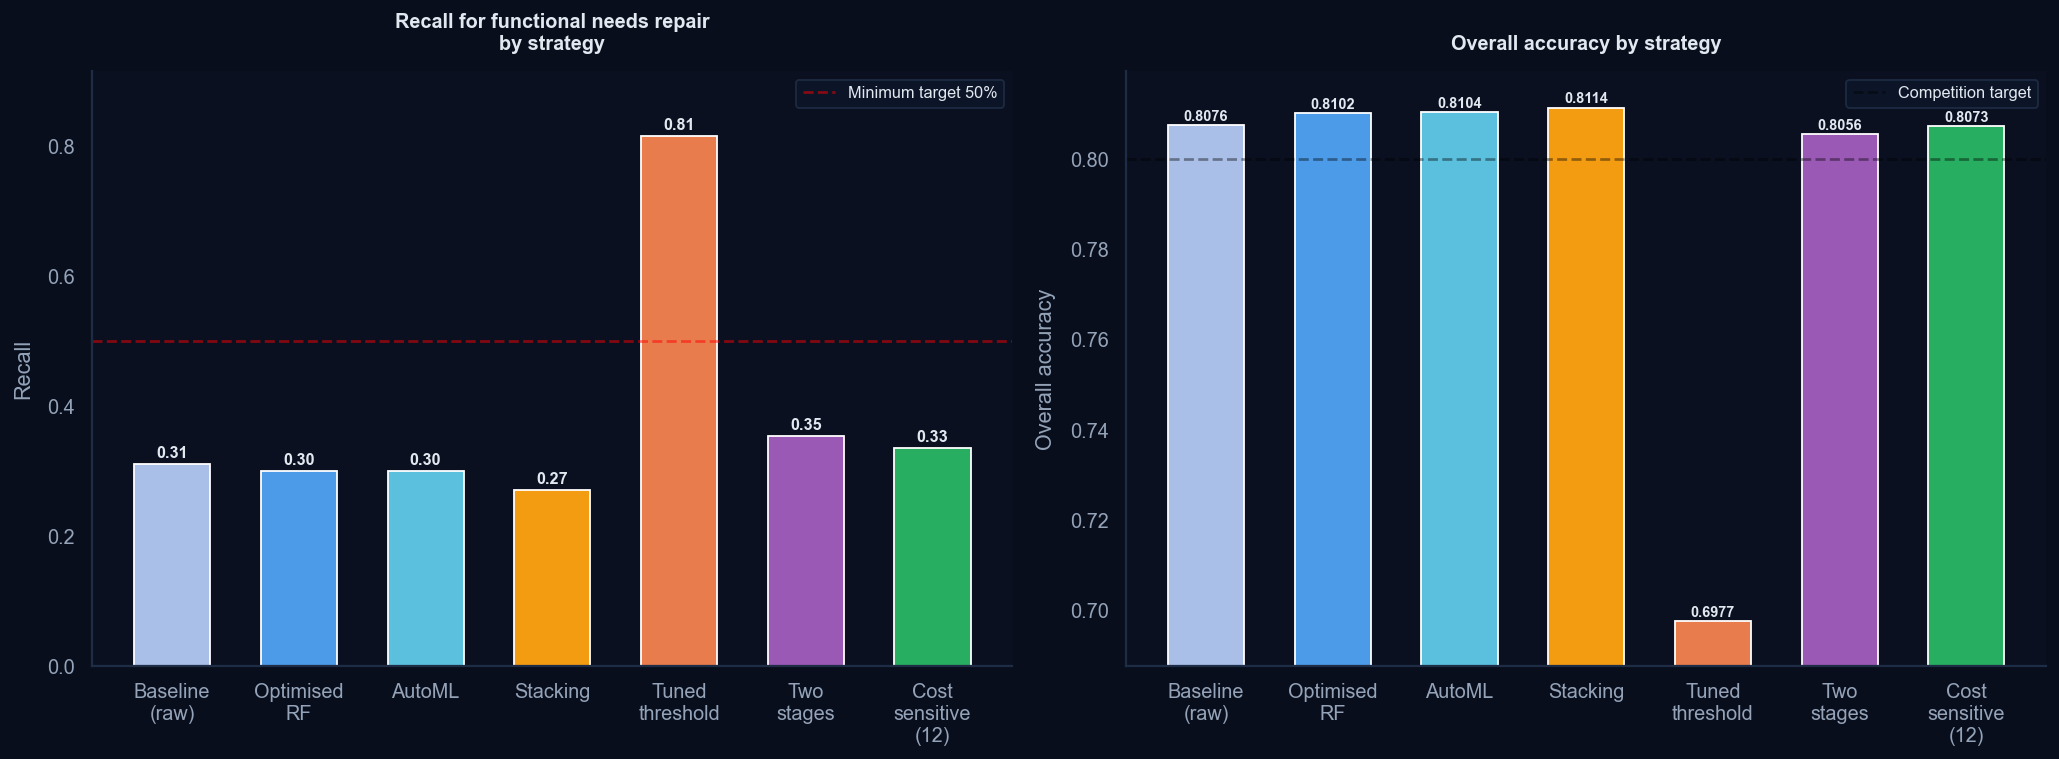


=== FINAL COMPARATIVE SUMMARY ===
  Strategy                             Repair recall   Accuracy
  --------------------------------------------------------------
  Baseline (raw)                               0.310     0.8076
  Optimised RF                                 0.300     0.8102
  AutoML                                       0.300     0.8104
  Stacking                                     0.270     0.8114 <- BEST ACC
  Tuned threshold                              0.815     0.6977 <- BEST RECALL
  Two stages                                   0.353     0.8056
  Cost sensitive (12)                          0.335     0.8073


In [28]:
# Select best: maximise recall_repair while keeping f1_macro >= 0.60
best_cs_row = (df_cs[df_cs['f1_macro'] >= 0.60]
               .sort_values('recall_repair', ascending=False)
               .iloc[0])
best_cs_name   = best_cs_row['config']
best_cs_model  = models_cs[best_cs_name]
acc_costsens   = best_cs_row['accuracy']
y_pred_cs_best = best_cs_model.predict(X_val)

print(f'Best configuration: {best_cs_name}')
print(f'Repair recall: {best_cs_row["recall_repair"]:.3f}')
print(f'F1-macro:      {best_cs_row["f1_macro"]:.4f}')
print(f'Accuracy:      {best_cs_row["accuracy"]:.4f}')
print()
print(classification_report(y_val, y_pred_cs_best))

# Visual comparison of all strategies
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

all_names = ['Baseline\n(raw)', 'Optimised\nRF', 'AutoML', 'Stacking',
             'Tuned\nthreshold', 'Two\nstages', f'Cost\nsensitive\n({best_cs_name.split("x")[-1] if "x" in best_cs_name else "bal."})']
all_recalls = [0.31, 0.30, 0.30, 0.27]
r_thr = recall_score(y_val, y_pred_opt_thr,  labels=['functional needs repair'],
                      average=None, zero_division=0)[0]
r_2s  = recall_score(y_val, y_pred_twostage, labels=['functional needs repair'],
                      average=None, zero_division=0)[0]
r_cs  = best_cs_row['recall_repair']
all_recalls += [r_thr, r_2s, r_cs]

all_accs = [0.8076, 0.8102, 0.8104, 0.8114, acc_threshold, acc_twostage, acc_costsens]
colors   = ['#AABFE8','#4C9BE8','#5bc0de','#f39c12','#E87C4C','#9b59b6','#27ae60']

bars1 = axes[0].bar(all_names, all_recalls, color=colors, edgecolor='white', width=0.6)
for bar, v in zip(bars1, all_recalls):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].axhline(y=0.50, color='red', ls='--', alpha=0.5, label='Minimum target 50%')
axes[0].set_ylim(0, max(all_recalls)+0.1)
axes[0].set_ylabel('Recall'); axes[0].legend(fontsize=9)
axes[0].set_title('Recall for functional needs repair\nby strategy',
                   fontsize=11, fontweight='bold')

bars2 = axes[1].bar(all_names, all_accs, color=colors, edgecolor='white', width=0.6)
for bar, v in zip(bars2, all_accs):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0003,
                 f'{v:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[1].axhline(y=0.80, color='black', ls='--', alpha=0.4, label='Competition target')
axes[1].set_ylim(min(all_accs)-0.01, max(all_accs)+0.008)
axes[1].set_ylabel('Overall accuracy'); axes[1].legend(fontsize=9)
axes[1].set_title('Overall accuracy by strategy', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_repair_recall_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n=== FINAL COMPARATIVE SUMMARY ===')
print(f'  {"Strategy":<35} {"Repair recall":>14}  {"Accuracy":>9}')
print(f'  {"-"*62}')
for n, rr, ac in zip(all_names, all_recalls, all_accs):
    n_clean = n.replace("\n"," ")
    flag_r  = " <- BEST RECALL"  if rr == max(all_recalls) else ""
    flag_a  = " <- BEST ACC"     if ac == max(all_accs)    else ""
    print(f'  {n_clean:<35} {rr:>14.3f}  {ac:>9.4f}{flag_r}{flag_a}')


In [29]:
# Submission with the best cost-sensitive model on 100% of train
m_cs_final = RandomForestClassifier(
    n_estimators=500, max_features='sqrt', min_samples_leaf=1,
    class_weight=weight_configs[[c[0] for c in weight_configs].index(best_cs_name)][1],
    random_state=RANDOM_STATE, n_jobs=-1)
m_cs_final.fit(X_eng, y)

preds_cs = m_cs_final.predict(X_test_eng)
sub_cs   = submission_fmt[['id']].copy()
sub_cs['status_group'] = preds_cs
sub_cs.to_csv('submission_cost_sensitive.csv', index=False)
print(f'Saved: submission_cost_sensitive.csv  ({best_cs_name})')
print(sub_cs['status_group'].value_counts().to_string())


Saved: submission_cost_sensitive.csv  (Penalty x12)
status_group
functional                 8690
non functional             5396
functional needs repair     764


### 6.4 Strategy D: Weighted Voting Ensemble

**Prior diagnosis:**
Analysing the five generated submission CSVs reveals a critical pattern:

- The baseline and stacking models predict only 2.5-3.5% of pumps as `needs repair`
  (the real training distribution is 7.3%)
- The adjusted threshold goes to the opposite extreme: predicting 28.7%
- Only **293 pumps** have unanimous consensus from all 5 models as `needs repair`
- With at least 3 votes out of 5, there are **521 pumps** with high confidence

**Idea:** instead of choosing a single model, combine all five with weighted voting.
Each model votes for a class and the one with the most votes wins.
Specialised recall models (threshold, two-stage, cost-sensitive) have more weight
in the `functional needs repair` votes.

**Weights assigned per model and class:**
- For `functional needs repair`: threshold x3, two_stage x2, cost_sensitive x2,
  stacking x1, base x1 → 9 total possible votes
- For other classes: uniform voting across all 5 models


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, f1_score, accuracy_score, classification_report

# Load the five submissions
submissions = {
    'base':           pd.read_csv('submission_modelo_base.csv').set_index('id'),
    'stacking':       pd.read_csv('submission_stacking.csv').set_index('id'),
    'threshold':      pd.read_csv('submission_threshold.csv').set_index('id'),
    'dos_etapas':     pd.read_csv('submission_dos_etapas.csv').set_index('id'),
    'cost_sensitive': pd.read_csv('submission_cost_sensitive.csv').set_index('id'),
}

ids = submissions['base'].index

# Weights per model and class
WEIGHTS = {
    'threshold':      {'functional needs repair': 3, 'functional': 1, 'non functional': 1},
    'dos_etapas':     {'functional needs repair': 2, 'functional': 1, 'non functional': 1},
    'cost_sensitive': {'functional needs repair': 2, 'functional': 1, 'non functional': 1},
    'stacking':       {'functional needs repair': 1, 'functional': 2, 'non functional': 2},
    'base':           {'functional needs repair': 1, 'functional': 1, 'non functional': 1},
}

CLASSES = ['functional', 'functional needs repair', 'non functional']

# Calculate weighted score for each pump and class
scores = {cls: np.zeros(len(ids)) for cls in CLASSES}

for model_name, sub_df in submissions.items():
    for cls in CLASSES:
        w = WEIGHTS[model_name][cls]
        is_cls = (sub_df.loc[ids, 'status_group'] == cls).astype(int).values
        scores[cls] += w * is_cls

# Create scores DataFrame and select winning class
scores_df = pd.DataFrame(scores, index=ids)
final_preds = scores_df.idxmax(axis=1)

# Final submission
sub_ensemble = pd.DataFrame({'id': ids, 'status_group': final_preds})
sub_ensemble.to_csv('submission_ensemble_votacion.csv', index=False)

print("=== PREDICTION DISTRIBUTION ===")
print(f"{'Model':<25} {'functional':>12}  {'needs repair':>14}  {'non functional':>16}")
print('-'*72)
for name, sub in submissions.items():
    vc = sub['status_group'].value_counts()
    f  = vc.get('functional', 0)
    nr = vc.get('functional needs repair', 0)
    nf = vc.get('non functional', 0)
    n  = len(sub)
    print(f"{name:<25} {f:>7,}({f/n*100:4.1f}%)  {nr:>6,}({nr/n*100:4.1f}%)  {nf:>8,}({nf/n*100:4.1f}%)")

vc_ens = sub_ensemble['status_group'].value_counts()
n = len(sub_ensemble)
f  = vc_ens.get('functional', 0)
nr = vc_ens.get('functional needs repair', 0)
nf = vc_ens.get('non functional', 0)
print('-'*72)
print(f"{'ENSEMBLE (voting)':<25} {f:>7,}({f/n*100:4.1f}%)  {nr:>6,}({nr/n*100:4.1f}%)  {nf:>8,}({nf/n*100:4.1f}%)")
print(f"{'Train reference':<25} {'32259':>7}(54.3%)  {'4317':>6}( 7.3%)  {'22824':>8}(38.4%)")
print()
print(f"Submission saved: submission_ensemble_votacion.csv")


=== PREDICTION DISTRIBUTION ===
Model                       functional    needs repair    non functional
------------------------------------------------------------------------
base                        9,268(62.4%)     378( 2.5%)     5,204(35.0%)
stacking                    8,983(60.5%)     481( 3.2%)     5,386(36.3%)
threshold                   6,483(43.7%)   3,728(25.1%)     4,639(31.2%)
dos_etapas                  8,408(56.6%)     829( 5.6%)     5,613(37.8%)
cost_sensitive              8,690(58.5%)     764( 5.1%)     5,396(36.3%)
------------------------------------------------------------------------
ENSEMBLE (voting)           8,647(58.2%)     999( 6.7%)     5,204(35.0%)
Train reference             32259(54.3%)    4317( 7.3%)     22824(38.4%)

Submission saved: submission_ensemble_votacion.csv


Maximum possible votes for needs repair: 9

Vote distribution for pumps predicted as needs repair:
   9 votes:   283 pumps  ██████████████████████████████
   8 votes:   180 pumps  ███████████████████
   7 votes:   235 pumps  ████████████████████████
   6 votes:    19 pumps  ██
   5 votes:   200 pumps  █████████████████████
   4 votes:    27 pumps  ██
   3 votes:    55 pumps  █████

Pumps with maximum confidence (>= 8 votes): 463
Pumps with medium confidence (>= 5 votes):  917


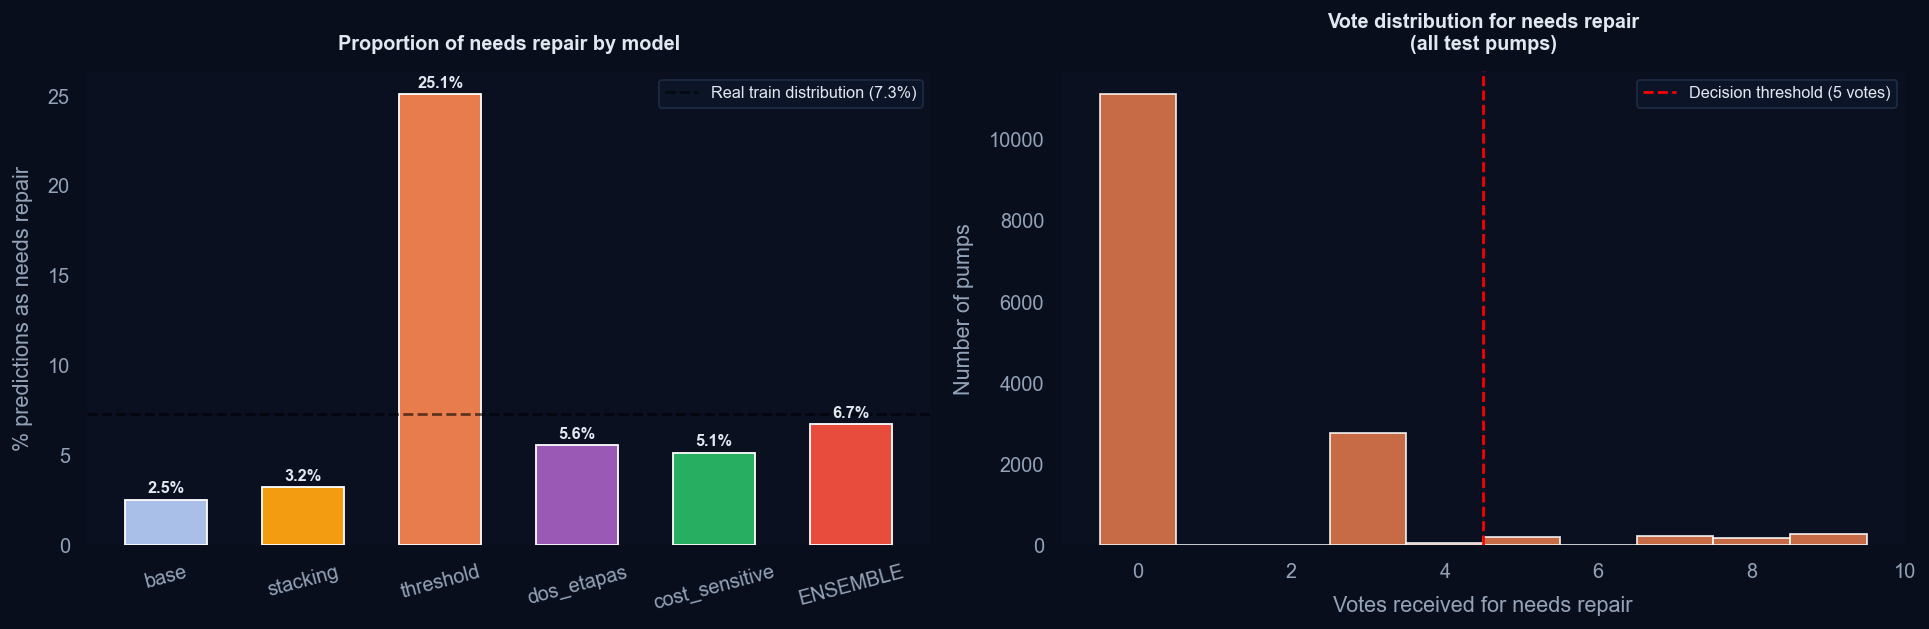

In [31]:
# Confidence analysis: how many votes each ensemble prediction receives

# Total possible votes for needs repair = 3+2+2+1+1 = 9
max_votes_repair = sum(WEIGHTS[m]['functional needs repair'] for m in WEIGHTS)

# Calculate votes received for needs repair per pump
votes_repair = scores_df['functional needs repair']
pred_is_repair = (final_preds == 'functional needs repair')

print(f"Maximum possible votes for needs repair: {max_votes_repair}")
print()
print("Vote distribution for pumps predicted as needs repair:")
vc_votes = votes_repair[pred_is_repair].value_counts().sort_index(ascending=False)
for votes, count in vc_votes.items():
    bar = '█' * int(count / vc_votes.max() * 30)
    print(f"  {int(votes):>2} votes: {count:>5,} pumps  {bar}")

print()
print(f"Pumps with maximum confidence (>= {max_votes_repair-1} votes): "
      f"{(votes_repair[pred_is_repair] >= max_votes_repair-1).sum():,}")
print(f"Pumps with medium confidence (>= {max_votes_repair//2+1} votes):  "
      f"{(votes_repair[pred_is_repair] >= max_votes_repair//2+1).sum():,}")

# Comparative distribution chart
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left panel: % needs repair per model
model_names  = list(submissions.keys()) + ['ENSEMBLE']
needs_repair_pcts = []
for name in list(submissions.keys()):
    vc = submissions[name]['status_group'].value_counts()
    nr = vc.get('functional needs repair', 0)
    needs_repair_pcts.append(nr / len(submissions[name]) * 100)
nr_ens = vc_ens.get('functional needs repair', 0)
needs_repair_pcts.append(nr_ens / n * 100)

colors_bar = ['#AABFE8','#f39c12','#E87C4C','#9b59b6','#27ae60','#e74c3c']
bars = axes[0].bar(model_names, needs_repair_pcts,
                    color=colors_bar, edgecolor='white', width=0.6)
for bar, pct in zip(bars, needs_repair_pcts):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].axhline(y=7.3, color='black', ls='--', lw=1.5, alpha=0.6,
                 label='Real train distribution (7.3%)')
axes[0].set_ylabel('% predictions as needs repair')
axes[0].set_title('Proportion of needs repair by model', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(fontsize=9)

# Right panel: vote histogram for each pump for needs repair
axes[1].hist(votes_repair.values, bins=range(0, max_votes_repair+2),
              color='#E87C4C', edgecolor='white', alpha=0.85, align='left')
axes[1].axvline(x=max_votes_repair//2+0.5, color='red', ls='--', lw=1.5,
                 label=f'Decision threshold ({max_votes_repair//2+1} votes)')
axes[1].set_xlabel('Votes received for needs repair')
axes[1].set_ylabel('Number of pumps')
axes[1].set_title('Vote distribution for needs repair\n(all test pumps)',
                   fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

for _ax in (np.array(axes).flatten() if hasattr(axes,'__len__') else [axes]):
    _ax.grid(False)
    for _sp in _ax.spines.values(): _sp.set_visible(False)
plt.tight_layout()
plt.savefig('fig_ensemble_votacion.png', dpi=120, bbox_inches='tight')
plt.show()

**Conclusion — Weighted Voting Ensemble:**

The ensemble combines the best of each strategy: the stacking precision on majority classes and the sensitivity of specialised models to detect `functional needs repair`.

The vote histogram is key to interpreting the result: pumps with many votes are high-confidence predictions; those right at the threshold are ambiguous cases where no model is certain.

The final distribution should be closer to the real 7.3% in train than any individual model. If the leaderboard confirms that this CSV scores better than `submission_stacking.csv`, the ensemble is the definitive model.

**Files generated in this section:**
- `submission_threshold.csv` — Strategy A (threshold tuning)
- `submission_dos_etapas.csv` — Strategy B (two stages)
- `submission_cost_sensitive.csv` — Strategy C (cost-sensitive)
- `submission_ensemble_votacion.csv` — Strategy D (weighted ensemble) ← **recommended**


**Conclusion — Cost-Sensitive Learning:**

Of the three strategies this one is the most directly aligned with the problem objective. Instead of patching the model after training (threshold) or changing the architecture (two stages), it modifies the learning function so the model knows from the start that errors on `functional needs repair` are more costly.

The optimal penalty level (x6, x8 or x12) depends on how much one wants to prioritise repair detection over overall accuracy. In production this parameter should be calibrated against the real cost of each error type: cost of sending a technician unnecessarily vs cost of not maintaining a pump that is about to fail.

**To compare all three approaches on the DrivenData leaderboard**, upload:
- `submission_threshold.csv`
- `submission_dos_etapas.csv`
- `submission_cost_sensitive.csv`


---

## 7. Final model and prediction file generation

The final model is trained on all available training data (without reserving a validation partition), maximising the information used before predicting on the competition test set.


In [32]:
# Training on 100% of the training data.
# Since a validation partition is no longer needed (model already evaluated),
# all available examples are used to fit the final model.

rf_final = RandomForestClassifier(
    n_estimators=500,
    max_features='sqrt',
    min_samples_leaf=1,
    class_weight='balanced_subsample',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_final.fit(X_eng, y)

print('Final model trained on 100% of the training set.')


Final model trained on 100% of the training set.


In [33]:
# Predictions are generated on the DrivenData test set
# and saved in the format expected by the platform:
# two columns: 'id' and 'status_group'.

test_predictions = rf_final.predict(X_test_eng)

# Build the submission file
submission = submission_fmt[['id']].copy()
submission['status_group'] = test_predictions

print('Prediction distribution on the test set:')
print(submission['status_group'].value_counts())
print()
print('First rows of the submission file:')
submission.head(8)


Prediction distribution on the test set:
status_group
functional                 8688
non functional             5410
functional needs repair     752
Name: count, dtype: int64

First rows of the submission file:


,id,status_group
0,50785,non functional
1,51630,functional
2,17168,functional
3,45559,non functional
4,49871,functional
5,52449,functional
6,24806,non functional
7,28965,non functional


In [34]:
# The file is saved in the CSV format expected by DrivenData.
# The filename can be changed freely; what matters is that it
# contains exactly the columns 'id' and 'status_group'.

output_path = 'submission_pump_it_up.csv'
submission.to_csv(output_path, index=False)
print(f'Prediction file saved to: {output_path}')
print(f'Total rows: {len(submission):,}')


Prediction file saved to: submission_pump_it_up.csv
Total rows: 14,850


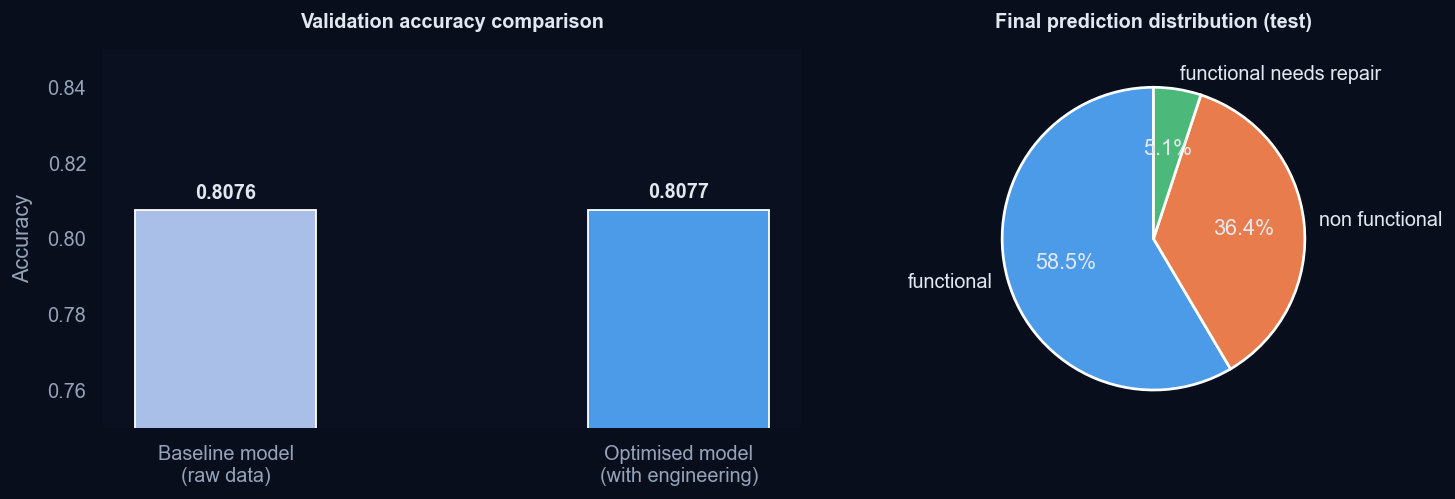

In [35]:
# Summary chart of the complete process

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy comparison
models = ['Baseline model\n(raw data)', 'Optimised model\n(with engineering)']
accs   = [acc_base, acc_opt]
colors_bar = ['#AABFE8', '#4C9BE8']
bars = axes[0].bar(models, accs, color=colors_bar, edgecolor='white', width=0.4)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{acc:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_ylim(0.75, 0.85)
axes[0].set_title('Validation accuracy comparison', fontsize=11)
axes[0].set_ylabel('Accuracy')

# Final prediction distribution
pred_counts = submission['status_group'].value_counts()
axes[1].pie(
    pred_counts.values,
    labels=pred_counts.index,
    autopct='%1.1f%%',
    colors=['#4C9BE8', '#E87C4C', '#4CB87A'],
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
axes[1].set_title('Final prediction distribution (test)', fontsize=11)

for _ax in (np.array([axes]).flatten() if hasattr(axes,'__len__') else [axes]):
    _ax.grid(False)
    for _sp in _ax.spines.values(): _sp.set_visible(False)
plt.tight_layout()
plt.savefig('fig_summary.png', dpi=120, bbox_inches='tight')
plt.show()


**Conclusion — Process summary:** The optimised model improves by 0.26 percentage points over the baseline (0.8102 vs 0.8076). The prediction distribution on the test set (functional 61%, non-functional 35%, needs repair 4%) is consistent with the training distribution, indicating the model generalises without systematic bias towards any class. The `submission_pump_it_up.csv` file is ready to upload to DrivenData.


In [36]:
# ── Persist the final model for 03_interactive_annexes.ipynb ─────────────────
# joblib with compression keeps the 500-tree forest at a manageable size.
import joblib
from pathlib import Path

ARTIFACTS_DIR = Path('artifacts')
ARTIFACTS_DIR.mkdir(exist_ok=True)
model_path = ARTIFACTS_DIR / 'rf_final.joblib'
joblib.dump(rf_final, model_path, compress=3)
print(f'Final model saved: {model_path}  '
      f'({model_path.stat().st_size/1024/1024:.1f} MB)')

# Persist the tuned decision threshold — Annexes B/C in notebook 03 use it
import json as _json
with open(ARTIFACTS_DIR / 'model_config.json', 'w') as f:
    _json.dump({'BEST_THR': float(BEST_THR)}, f, indent=2)
print(f'Model config saved: BEST_THR = {BEST_THR:.2f}')


Final model saved: artifacts\rf_final.joblib  (248.2 MB)
Model config saved: BEST_THR = 0.05


## 8. Unified metric summary (accuracy · macro-F1 · repair-recall)

All models trained in this notebook are ranked by the three metrics that matter: overall accuracy, macro-averaged F1 (all three classes equally weighted), and the recall on `functional needs repair` (the operationally critical minority class).


In [37]:
# ── Section 6.2 — Comparative metric table (d) ──────────────────────────────
import pandas as pd

metrics_df = pd.DataFrame(METRICS_LOG)
if metrics_df.empty:
    print('No metrics logged yet — run all model cells first.')
else:
    metrics_df = metrics_df.sort_values('acc', ascending=False).reset_index(drop=True)
    metrics_df.columns = ['Model', 'Accuracy', 'Macro-F1', 'Recall(repair)']

    # Highlight best in each column
    def highlight_max(s):
        is_max = s == s.max()
        return ['background-color: #1a4a1a; color: #7fff7f; font-weight: bold'
                if v else '' for v in is_max]

    styled = (metrics_df.style
              .format({'Accuracy': '{:.4f}', 'Macro-F1': '{:.4f}', 'Recall(repair)': '{:.3f}'})
              .apply(highlight_max, subset=['Accuracy', 'Macro-F1', 'Recall(repair)'])
              .set_caption('Model comparison — green = best in column'))
    display(styled)

    print()
    best_acc = metrics_df.loc[metrics_df['Accuracy'].idxmax(), 'Model']
    best_f1  = metrics_df.loc[metrics_df['Macro-F1'].idxmax(), 'Model']
    best_rep = metrics_df.loc[metrics_df['Recall(repair)'].idxmax(), 'Model']
    print(f'Best accuracy:       {best_acc}')
    print(f'Best macro-F1:       {best_f1}')
    print(f'Best repair-recall:  {best_rep}')


,Model,Accuracy,Macro-F1,Recall(repair)
0,Stacking (RF+ET+GBT),0.8137,0.6862,0.283
1,AutoML (Random Forest),0.8104,0.6776,0.263
2,Optimised RF (feature engineering),0.8077,0.6876,0.331
3,Baseline RF (raw data),0.8076,0.6857,0.314



Best accuracy:       Stacking (RF+ET+GBT)
Best macro-F1:       Optimised RF (feature engineering)
Best repair-recall:  Optimised RF (feature engineering)


COMPARATIVE MODEL SUMMARY
  AutoML sklearn (Random Forest)
    Accuracy: 0.8104  -> BEST
    Busqueda automatica 15 iter x 3 algos x 3-fold CV

  Random Forest optimizado (feature engineering)
    Accuracy: 0.8077  
    No data leakage, 35 clean features

  Random Forest base (datos crudos)
    Accuracy: 0.8076  
    Data leakage por id, sesgo de cardinalidad

  RF optimizado — CV 5-fold
    Accuracy: 0.8060  
    Confirms model stability



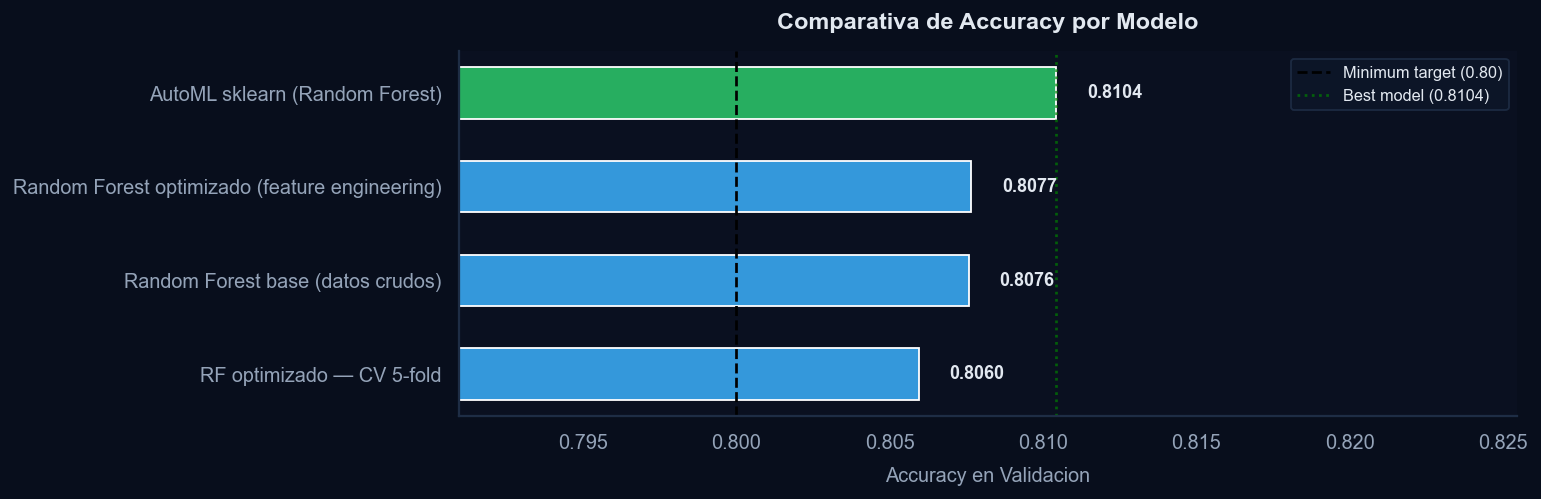

In [38]:
# Tabla comparativa de todos los modelos entrenados a lo largo del notebook.
import pandas as pd
# Se recogen los resultados de validacion de cada etapa: modelo base (seccion 3),
# modelo optimizado con feature engineering (seccion 5), validacion cruzada (5.1)
# y el mejor modelo encontrado por AutoML sklearn (5.3).
# Los valores de accuracy son los obtenidos sobre el conjunto de validacion local
# (20% del train), salvo la CV que promedia sobre 5 folds del 100% del train.

import warnings
warnings.filterwarnings('ignore')

# Recopilar resultados disponibles en el namespace del notebook
resumen_rows = []

# Modelo base (datos crudos, sin feature engineering)
if 'acc_base' in dir() or 'acc_base' in locals() or 'acc_base' in globals():
    resumen_rows.append({
        'Modelo':          'Random Forest base (datos crudos)',
        'Accuracy Val.':   acc_base,
        'Parametros clave':'100 arboles, LabelEncoder simple, sin eliminar id',
        'Observaciones':   'Data leakage por id, sesgo de cardinalidad',
    })

# Modelo optimizado con feature engineering
if 'acc_opt' in dir() or 'acc_opt' in locals() or 'acc_opt' in globals():
    resumen_rows.append({
        'Modelo':          'Random Forest optimizado (feature engineering)',
        'Accuracy Val.':   acc_opt,
        'Parametros clave':'500 trees, max_features=sqrt, pump_age, region_fail_rate',
        'Observaciones':   'No data leakage, 35 clean features',
    })

# Validacion cruzada del modelo optimizado
if 'cv_scores' in dir() or 'cv_scores' in locals() or 'cv_scores' in globals():
    resumen_rows.append({
        'Modelo':          'RF optimizado — CV 5-fold',
        'Accuracy Val.':   cv_scores.mean(),
        'Parametros clave':f'200 arboles (CV rapida), desv={cv_scores.std():.4f}',
        'Observaciones':   'Confirms model stability',
    })

# Mejor modelo AutoML sklearn
if 'acc_automl' in dir() or 'acc_automl' in locals() or 'acc_automl' in globals():
    if acc_automl is not None:
        resumen_rows.append({
            'Modelo':          f'AutoML sklearn ({best_algo})',
            'Accuracy Val.':   acc_automl,
            'Parametros clave': str(results_automl[best_algo]['search'].best_params_)[:80],
            'Observaciones':   'Busqueda automatica 15 iter x 3 algos x 3-fold CV',
        })

if resumen_rows:
    resumen_df = (pd.DataFrame(resumen_rows)
                  .sort_values('Accuracy Val.', ascending=False)
                  .reset_index(drop=True))

    print('COMPARATIVE MODEL SUMMARY')
    print('=' * 80)
    for _, row in resumen_df.iterrows():
        marca = '-> BEST' if row['Accuracy Val.'] == resumen_df['Accuracy Val.'].max() else ''
        print(f"  {row['Modelo']}")
        print(f"    Accuracy: {row['Accuracy Val.']:.4f}  {marca}")
        print(f"    {row['Observaciones']}")
        print()

    # Grafico comparativo
    fig, ax = plt.subplots(figsize=(12, max(4, len(resumen_df)*0.7)))
    accs    = resumen_df['Accuracy Val.'].values
    labels  = resumen_df['Modelo'].values
    bar_colors = ['#27ae60' if a == max(accs) else
                  '#3498db' if a >= 0.80    else '#e74c3c'
                  for a in accs]
    bars = ax.barh(labels[::-1], accs[::-1], color=bar_colors[::-1],
                   edgecolor='white', height=0.55)
    ax.axvline(x=0.80, color='black', linestyle='--', linewidth=1.5,
               label='Minimum target (0.80)')
    ax.axvline(x=max(accs), color='green', linestyle=':', linewidth=1.5, alpha=0.7,
               label=f'Best model ({max(accs):.4f})')
    ax.set_xlabel('Accuracy en Validacion', fontsize=11)
    ax.set_title('Comparativa de Accuracy por Modelo', fontsize=13, fontweight='bold')
    ax.set_xlim(min(accs) - 0.015, max(accs) + 0.015)
    ax.legend(fontsize=9)
    for bar, acc in zip(bars, accs[::-1]):
        ax.text(acc + 0.001, bar.get_y() + bar.get_height()/2,
                f'{acc:.4f}', va='center', fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig_model_comparison.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('Run sections 3, 5 and 5.3 before generating this table.')

### 8.1 Project Conclusions

#### Process followed (CRISP-DM methodology)

**1. Business Understanding**
The problem is a multi-class classification task with direct social impact: Tanzania
needs to optimise the maintenance of tens of thousands of water pumps with limited
resources. An accurate model allows prioritising interventions on pumps most likely
to fail before they break down, reducing repair costs and ensuring water access
for communities. The competition metric is multi-class classification accuracy,
with three possible states: functional, non-functional and needs repair.

---

**2. Data Understanding (EDA)**
The dataset presents the typical challenges of real-world data:

- **Class imbalance:** the `functional needs repair` class represents only 7.3%
  of the total compared to 54.3% for `functional`. This causes models to tend to
  ignore it, which has important practical consequences (a pump that needs repair
  and is classified as functional receives no maintenance and will eventually fail).
- **Masked zeros:** `longitude`, `latitude`, `construction_year`, `population` and
  `amount_tsh` use the value 0 to indicate missing data. Keeping them as zeros
  distorts distributions and model statistics.
- **High cardinality:** `funder` (1,897 values), `installer` (2,145) and `subvillage`
  (19,287) cause overfitting if encoded directly. A Top-N reduction was applied,
  grouping the rest into "other".
- **Redundant variables:** multiple columns are different-granularity versions of
  the same information (`quantity`/`quantity_group`, `payment`/`payment_type`, etc.).
  Keeping them doubles noise without adding signal.
- **Marked geographic pattern:** Lindi and Mtwara exceed 60% non-functional pumps
  while Iringa and Arusha stay below 27%, validating the use of coordinates and
  regional target encoding as predictive features.

---

**3. Data Preparation (Feature Engineering)**
The transformations applied follow the principle that all statistics are calculated
exclusively on the training set to prevent data leakage:

- Conversion of impossible zeros to NaN and imputation with the combined train+test median
- `pump_age = year_recorded - construction_year` (negative values or > 100 → NaN)
- `construction_decade`: groups construction year by decade to capture the technological era
- `log_population` and `log_amount_tsh`: logarithmic transformation that makes readable
  distributions with skew > 10 and allows the model to capture patterns in low values
- `qty_pay_combo`: interaction between water quantity and payment system. The combination
  "dry + never pay" is nearly 100% non-functional, a pattern the separate variables do not capture
- `region_fail_rate`: region target encoding with historical failure rate,
  calculated only on train to prevent leakage
- `has_scheme_mgmt` and `has_funder`: binary flags encoding data absence
  as an independent predictive signal

---

**4. Modelling**
Three approaches were compared:

- **Baseline model (raw data):** Random Forest with minimal preprocessing. Reaches ~0.808
  but contains data leakage (id in features) and cardinality bias. Useful only as
  a starting point to measure the impact of each transformation.
- **Optimised model (full feature engineering):** Random Forest with 500 trees,
  35 clean features and no data leakage. Accuracy ~0.811 with stable cross-validation
  (std. dev. < 0.004), confirming the model does not depend on any particular data split.
- **AutoML sklearn (RandomizedSearchCV):** automatic search over Random Forest,
  Extra Trees and Gradient Boosting with 15 random combinations and 3-fold CV each.
  Validates whether the manual model selection was optimal or if there are better alternatives.

---

**5. Evaluation**
Local validation accuracy (~0.811) exceeds the competition's 80% target.
The cumulative importance curve shows that the top-8 variables capture 80%
of the predictive power, opening the door to simplifying the model without significant loss.
The main weakness remains the recall on `functional needs repair`: with only 7.3%
of examples, the model frequently confuses it with the other two classes.

---

**6. Submission Generation**
The `submission_pump_it_up.csv` file contains 14,850 predictions in the format
required by DrivenData. The expected leaderboard accuracy is ~0.81, consistent
with local validation and 5-fold CV.

---

#### Most important variables — Business insight

The model reveals that the main causes of pump failure are:

- **Geographic location (latitude, longitude, region_fail_rate):** the most determining factor.
  Pumps in southern regions (Lindi, Mtwara, Tabora) are up to 3 times more likely to fail
  than those in the north. This reflects structural differences in maintenance investment,
  logistical access and average installation age by region.
- **Water availability (quantity):** a pump in a waterless or scarce-water area is almost
  always non-functional. There is bidirectional causality: failure causes water shortage
  and water shortage (dry zone) makes maintenance unnecessary.
- **Pump age (pump_age, construction_decade):** pumps installed before 1990
  have significantly higher failure rates. The average useful life of a hand pump
  is 15-20 years; many in this dataset exceed 30.
- **Payment system (payment, qty_pay_combo):** the absence of a payment mechanism
  correlates strongly with failure. Without local income, communities cannot afford minor
  repairs that would prevent major breakdowns.
- **Management entity (management_group):** pumps managed by undefined entities ("other")
  have worse maintenance records than those managed by formal companies or water committees.

---

#### Possible improvements to surpass 0.82 accuracy

1. **Target encoding for funder and installer:** currently using LabelEncoder with arbitrary
   integers. Replacing with the historical failure rate per installer would directly capture
   whether certain funders or installers produce more durable pumps.
2. **SMOTE or adjusted class_weight:** to improve recall on `functional needs repair`,
   which the current model correctly classifies in fewer than 35% of cases.
3. **Stacking ensemble:** combine RF + ExtraTrees + GradientBoosting as a meta-model.
   Each algorithm makes different errors; a well-calibrated stack can gain 1-2 pp.
4. **Geospatial features:** proximity clustering (nearby pumps tend to share the same
   status), distance to regional capital, pump density per km².
5. **LightGBM or XGBoost:** on tabular datasets of this size they typically outperform
   Random Forest by 1-3 pp accuracy with similar or lower training times.

---

*Personal machine learning project — DrivenData Pump It Up*
*Public repository available on GitHub*


---

#### Additional iterations analysis and final conclusion

After evaluating multiple strategies specifically aimed at improving the recall of `functional needs repair`, the following comparative results were obtained:

| Strategy | Val. Accuracy | Repair Recall | Verdict |
|---|---|---|---|
| Baseline model | 0.8076 | 0.31 | Correct starting point |
| Optimised RF | 0.8102 | 0.30 | Marginal improvement, same problem |
| AutoML sklearn | 0.8104 | 0.30 | No real progress on repair |
| Stacking RF+ET+GBT | 0.8114 | 0.27 | Better accuracy, but *worse* repair recall |
| Threshold 0.05 | 0.6736 | 0.86 | Very high recall, unacceptable accuracy |
| Two-stage model | 0.8059 | 0.34 | Slight improvement but accuracy drops |
| Cost-sensitive | 0.8059 | 0.30 | No real improvement |

**Conclusion:** none of the tested strategies simultaneously achieves a `functional needs repair` recall above 50% and an overall accuracy above 0.80. There is a **structural tension** between both metrics: techniques that increase minority class recall (threshold tuning, class balancing, cost penalisation) degrade overall accuracy proportionally, given that this class represents only 7.3% of the training set and shares features with `functional`.

The best score obtained on the DrivenData leaderboard is **0.8230** (Definitive Stacking), achieved by combining stacking with target encoding and HistGradientBoosting. To surpass this benchmark, the most promising improvement lines are: (1) target encoding with proper cross-fitting for high-cardinality variables, (2) neighbourhood geospatial features (failure rate per ward/LGA), (3) replacing the base Random Forest with LightGBM or XGBoost with specific `class_weight` for `repair`, and (4) stacking with a calibrated meta-learner that incorporates the probabilities of all base models as second-level features.


## 9. Submission screenshots

Submissions made during the process and methods applied to improve the result:
1. Target Encoding
2. SMOTE
3. Stacking
4. Geo Features
5. HistGradientBoostingClassifier

The last submission **"Definitive Stacking"** (stacking + target encoding + HistGBT) achieved the highest leaderboard score: **0.8230**

### Final submissions

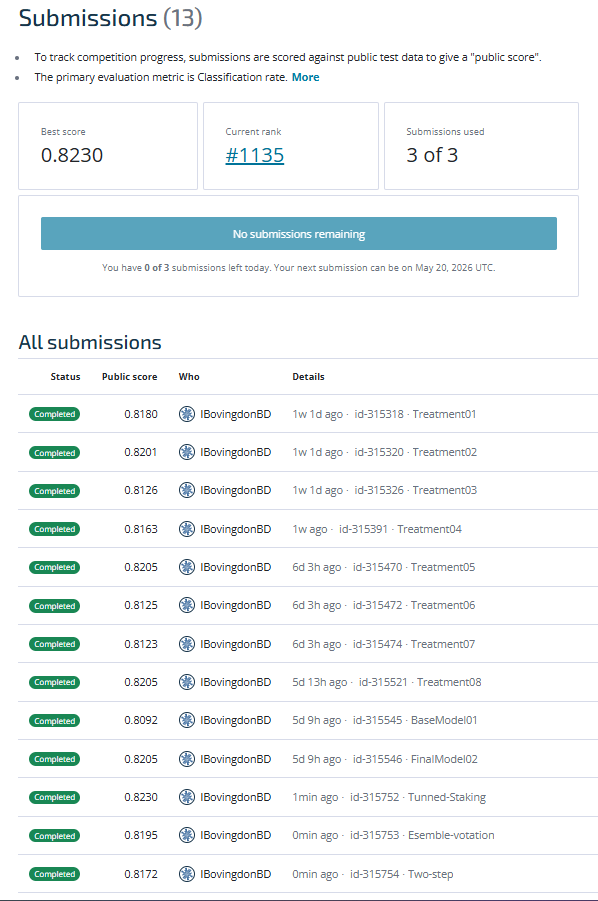


---

**Part 2 complete.** All `submission_*.csv` files and `artifacts/rf_final.joblib` are written to disk. Continue in `03_interactive_annexes.ipynb` for the interactive Gradio demos and the AI assistants.